In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def perform_eda(file_path):


    try:
        df = pd.read_csv(file_path, encoding="latin1")
    except UnicodeDecodeError:
        df = pd.read_csv(file_path)

    print("="*80)
    print("DATASET OVERVIEW")
    print("="*80)
    print("Shape :", df.shape)
    print("\nColumns\n", df.columns.tolist())

    print("\nInfo")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nSummary")
    print(df.describe(include="all"))

    print("\nMissing Values")
    print(df.isnull().sum())

    if df.isnull().sum().sum() > 0:
        sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
        plt.title("Missing Value Heatmap")
        plt.show()

    dup = df.duplicated().sum()
    print("\nDuplicate Rows :", dup)
    print("Duplicate Percentage : {:.2f}%".format((dup/len(df))*100))

    #  SMS Spam 
    if "v1" in df.columns and "v2" in df.columns:
        df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")
        df.columns = ["Label", "Message"]
        df["Length"] = df["Message"].str.len()

        sns.countplot(data=df, x="Label")
        plt.title("Spam vs Ham")
        plt.show()

        sns.histplot(df["Length"], kde=True)
        plt.title("Message Length Distribution")
        plt.show()

        sns.boxplot(data=df, x="Label", y="Length")
        plt.title("Message Length Boxplot")
        plt.show()

        sns.violinplot(data=df, x="Label", y="Length")
        plt.title("Message Length Violin Plot")
        plt.show()

        stats.probplot(df["Length"], dist="norm", plot=plt)
        plt.title("QQ Plot")
        plt.show()

        plt.scatter(range(len(df)), df["Length"], s=8)
        plt.title("Length Scatter")
        plt.xlabel("Message Index")
        plt.ylabel("Length")
        plt.show()

        print(df.groupby("Label")["Length"].describe())
        return

    #  Spambase 
    if "class" in df.columns and df.shape[1] == 58:
        sns.countplot(data=df, x="class")
        plt.title("Spam vs Non-Spam")
        plt.show()

        print("\nClass Distribution")
        print(df["class"].value_counts())

        print("\nClass Percentage")
        print((df["class"].value_counts(normalize=True) * 100).round(2))

        

    # MNIST 
    if "label" in df.columns and df.shape[1] == 785:
        sns.countplot(data=df, x="label")
        plt.title("Digit Distribution")
        plt.show()

        plt.figure(figsize=(12,5))
        for i in range(10):
            plt.subplot(2,5,i+1)
            plt.imshow(df.iloc[i,1:].values.reshape(28,28), cmap="gray")
            plt.title(df.iloc[i,0])
            plt.axis("off")
        plt.tight_layout()
        plt.show()

        pixels = df.iloc[:,1:].values.flatten()

        sns.histplot(pixels, bins=40)
        plt.title("Pixel Distribution")
        plt.show()

        sns.boxplot(x=pixels)
        plt.title("Pixel Boxplot")
        plt.show()

        sns.violinplot(x=pixels)
        plt.title("Pixel Violin Plot")
        plt.show()

        stats.probplot(pixels[:5000], dist="norm", plot=plt)
        plt.title("Pixel QQ Plot")
        plt.show()

        print(df["label"].value_counts())
        return

    # Diabetes
    if "Outcome" in df.columns:
        cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
        print("\nPossible Missing Values Stored as Zero")
        for c in cols:
            if c in df.columns:
                print(f"{c}: {(df[c]==0).sum()}")

    num = df.select_dtypes(include=np.number).columns.tolist()
    cat = df.select_dtypes(exclude=np.number).columns.tolist()

    print("\nSkewness")
    print(df[num].skew())

    # Histograms
    for c in num:
        sns.histplot(df[c], kde=True, bins=30)
        plt.title(f"Histogram - {c}")
        plt.show()

    # Boxplots
    for c in num:
        sns.boxplot(x=df[c])
        plt.title(f"Boxplot - {c}")
        plt.show()

    print("\nOutlier Count (IQR Method)")
    for c in num:
        Q1 = df[c].quantile(0.25)
        Q3 = df[c].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[c] < Q1 - 1.5*IQR) | (df[c] > Q3 + 1.5*IQR)]
        print(f"{c}: {len(outliers)}")

    # Violin
    for c in num:
        sns.violinplot(x=df[c])
        plt.title(f"Violin - {c}")
        plt.show()

    # Countplots
    for c in cat:
        sns.countplot(data=df, x=c)
        plt.xticks(rotation=45)
        plt.title(f"Countplot - {c}")
        plt.tight_layout()
        plt.show()

    # Heatmap
    if len(num) > 1:
        sns.heatmap(df[num].corr(), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.show()

    # Pairplot
    if len(num) <= 8 and len(df) <= 5000:
        hue = None
        for h in ["Species","species","Loan_Status","Outcome",
                  "target","Target","Class","class","Survived"]:
            if h in df.columns:
                hue = h
                break

        sns.pairplot(df, hue=hue)
        plt.show()

    # QQ Plots
    for c in num:
        stats.probplot(df[c].dropna(), dist="norm", plot=plt)
        plt.title(f"QQ Plot - {c}")
        plt.show()

    print("\nEDA Completed.")


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\sathi\AppData\Local\Temp\ipykernel_21776\2200739549.py:1: SyntaxWarning: invalid escape sequence '\S'
  perform_eda("D:\Semester-5\Machine Learning - Lab\Assignment-2\dataset\spambase_csv.csv")


DATASET OVERVIEW
Shape : (4601, 58)

Columns
 ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 

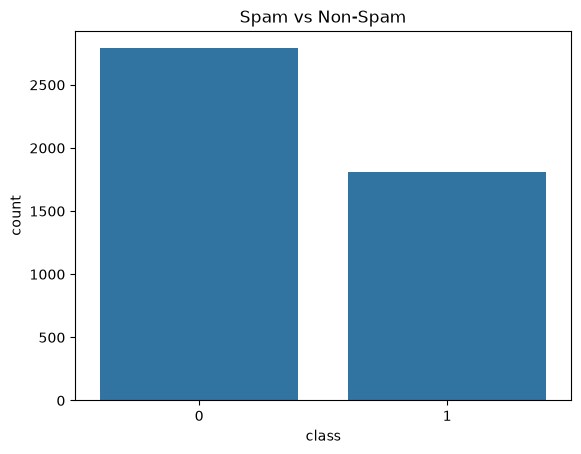


Class Distribution
class
0    2788
1    1813
Name: count, dtype: int64

Class Percentage
class
0    60.6
1    39.4
Name: proportion, dtype: float64

Skewness
word_freq_make                 5.675639
word_freq_address             10.086811
word_freq_all                  3.009249
word_freq_3d                  26.227744
word_freq_our                  4.747126
word_freq_over                 5.956953
word_freq_remove               6.765580
word_freq_internet             9.724848
word_freq_order                5.226067
word_freq_mail                 8.487810
word_freq_receive              5.510250
word_freq_will                 2.867354
word_freq_people               6.955548
word_freq_report              11.754645
word_freq_addresses            6.971041
word_freq_free                10.763594
word_freq_business             5.688642
word_freq_email                5.413754
word_freq_you                  1.591674
word_freq_credit              14.602587
word_freq_your                 2.435527
w

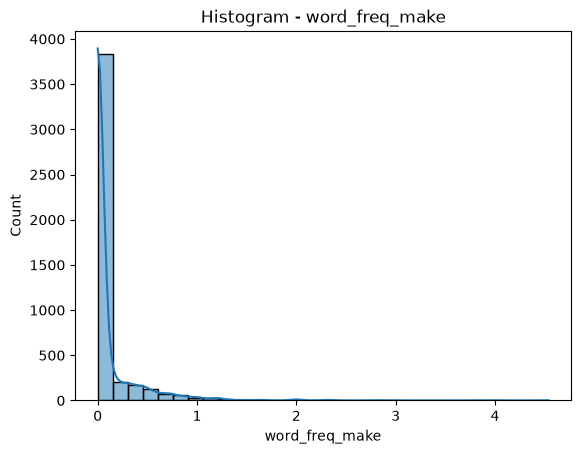

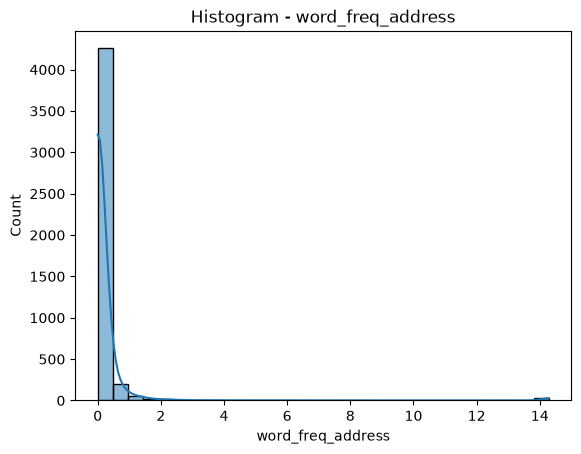

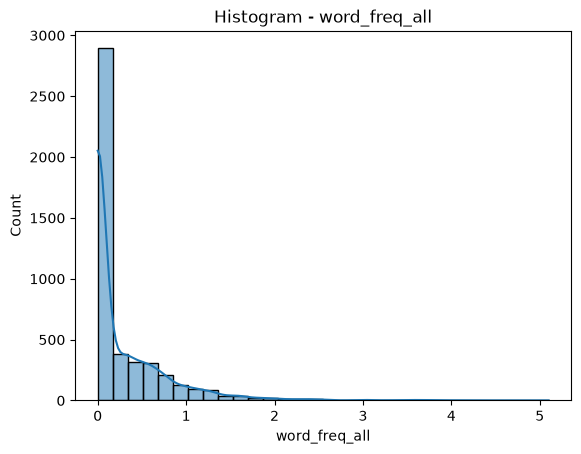

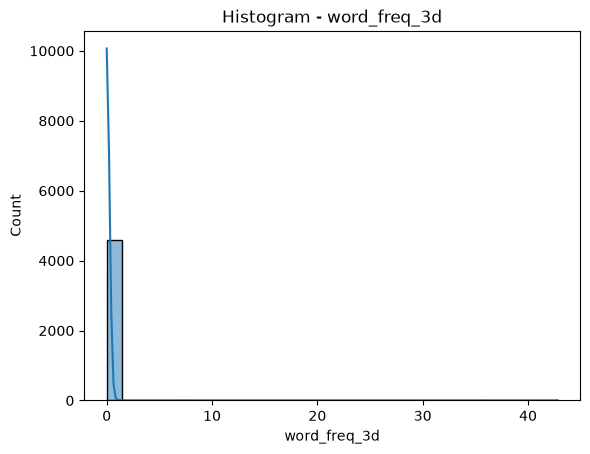

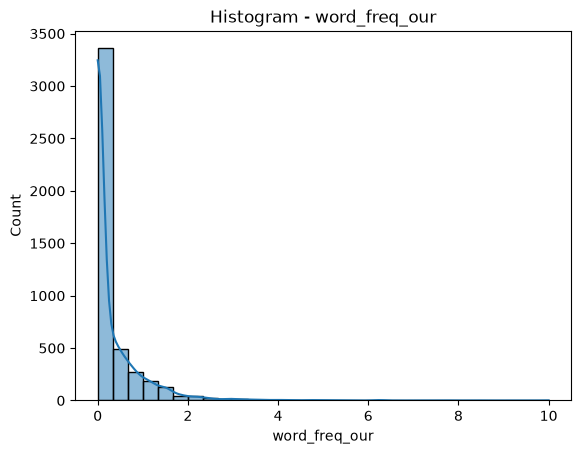

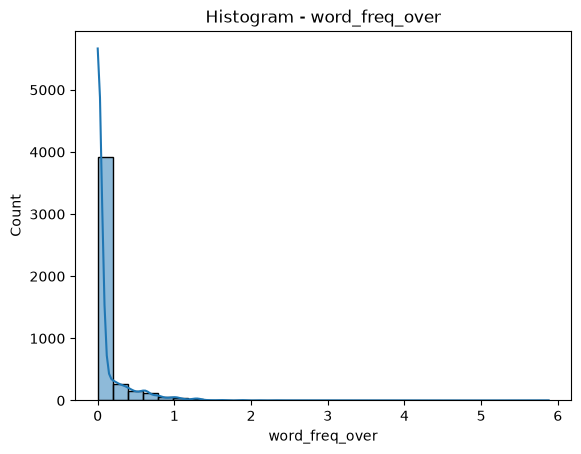

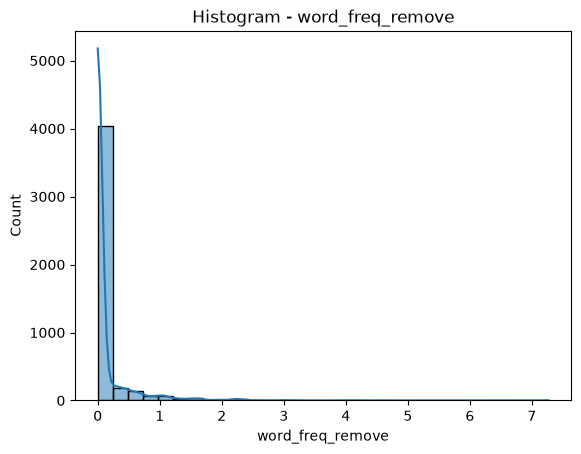

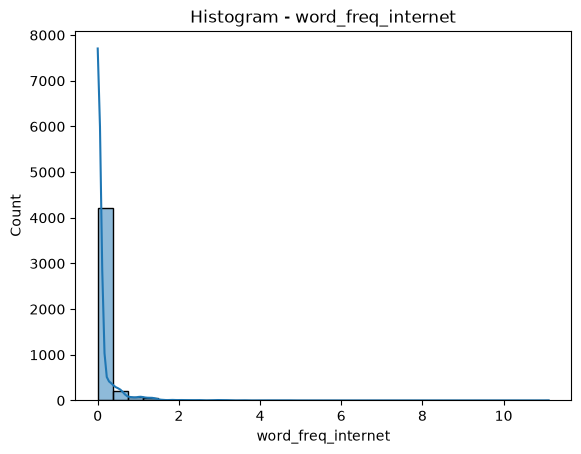

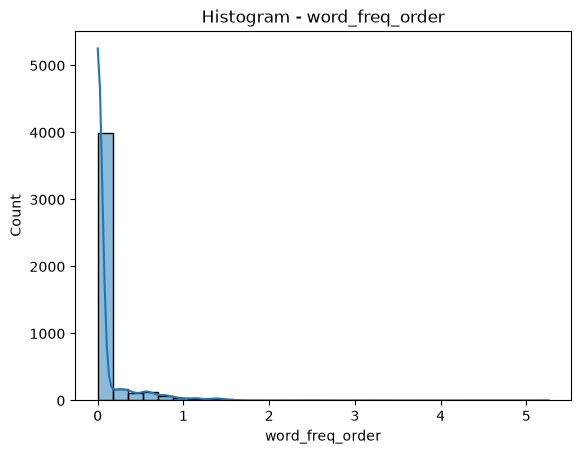

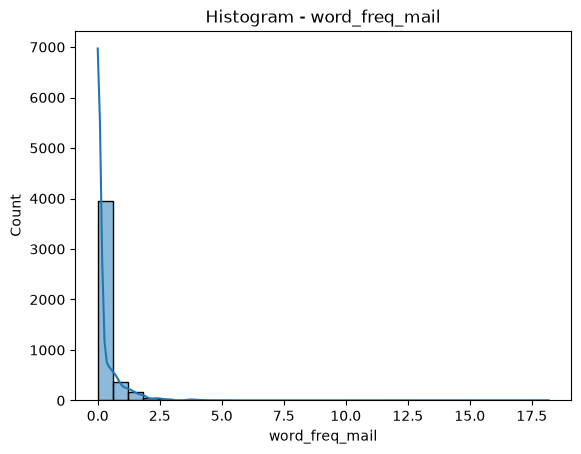

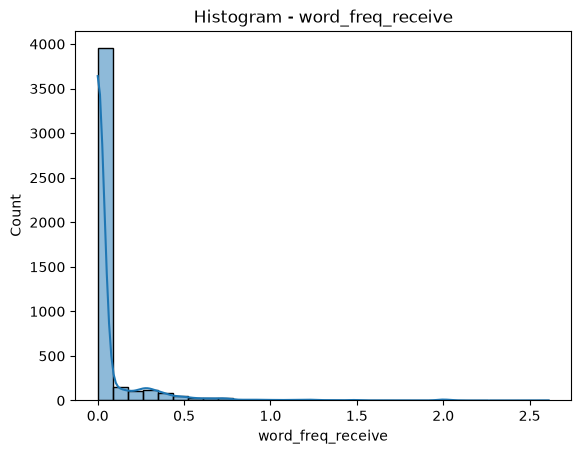

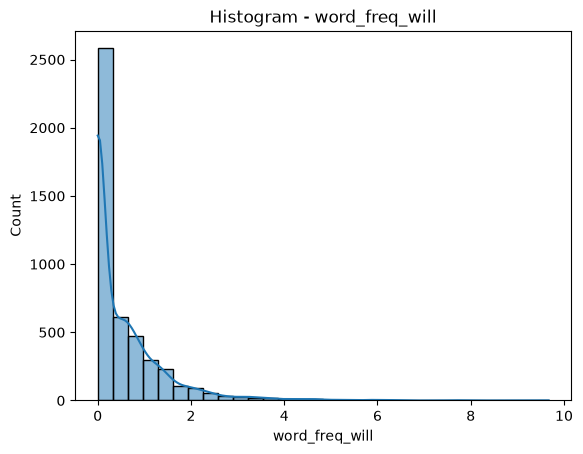

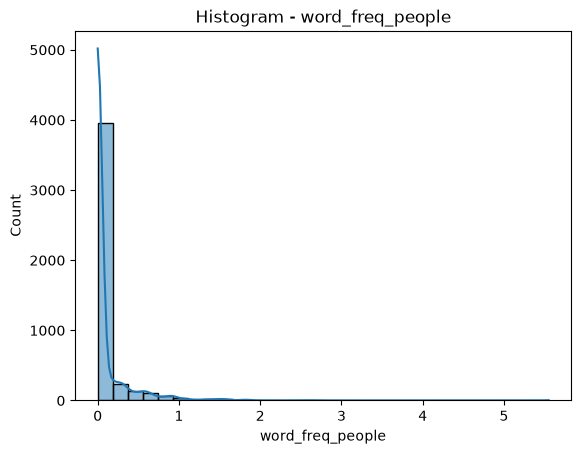

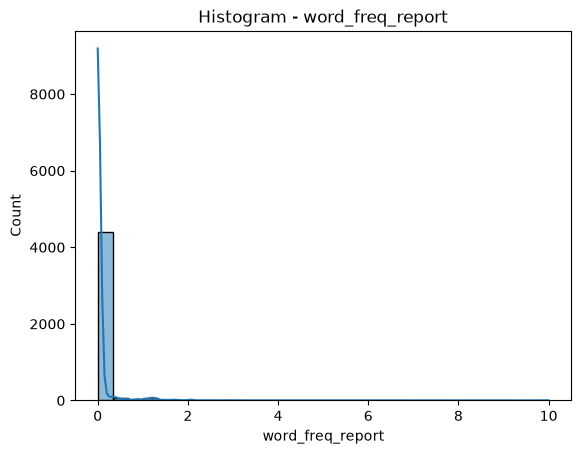

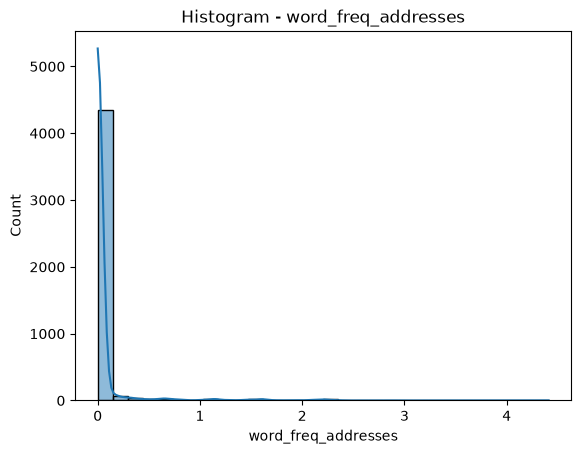

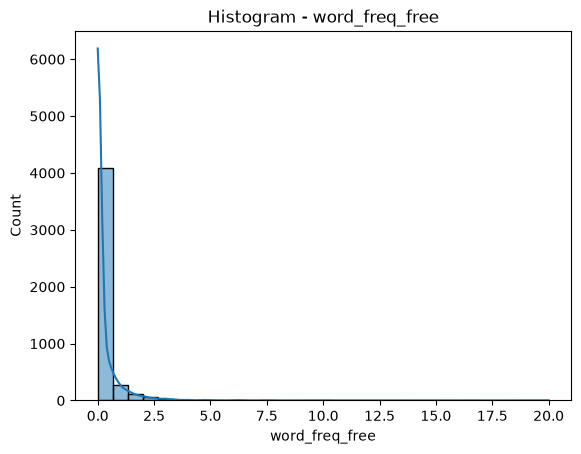

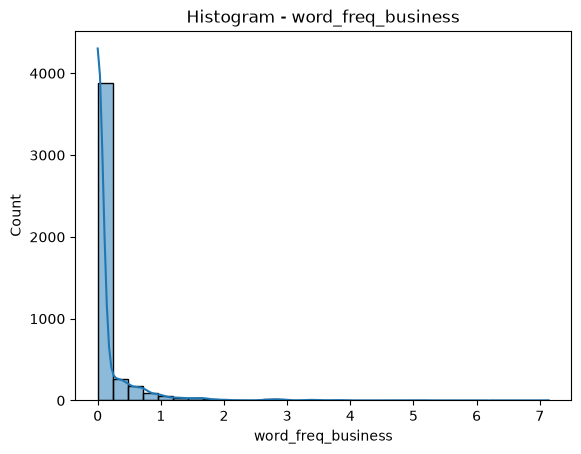

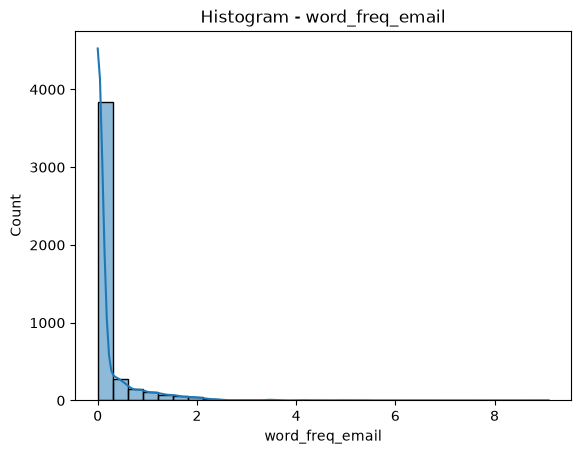

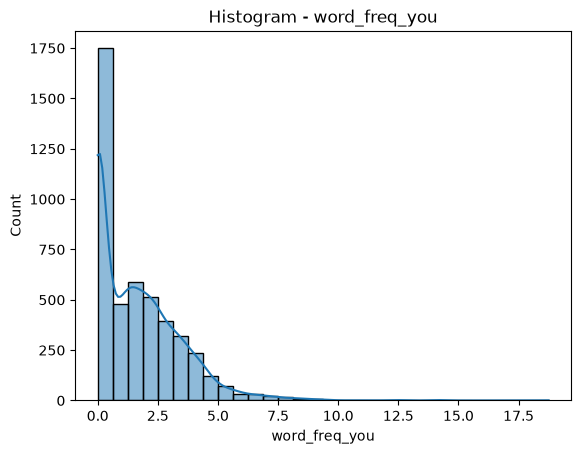

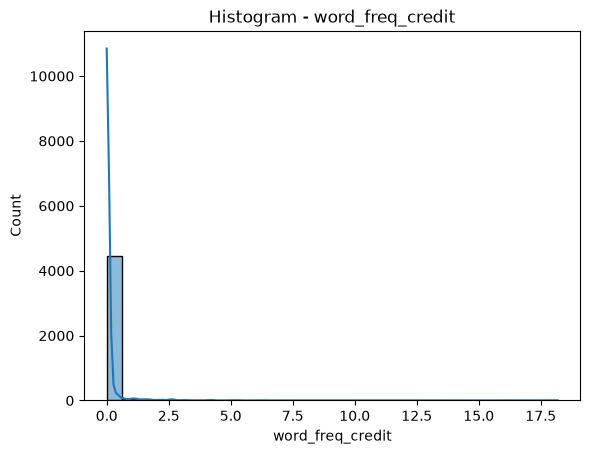

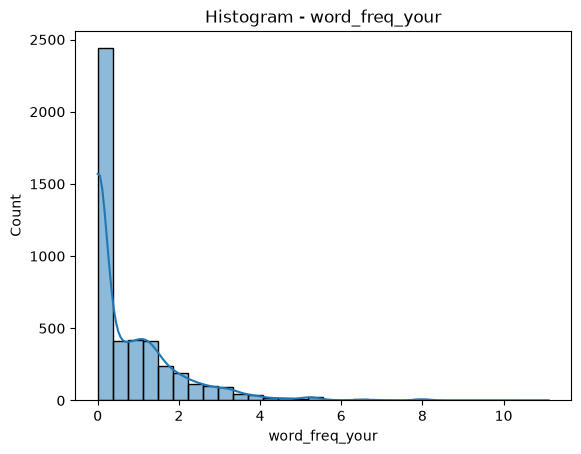

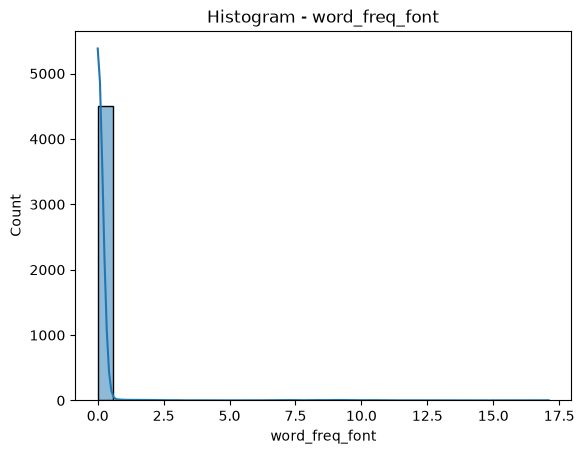

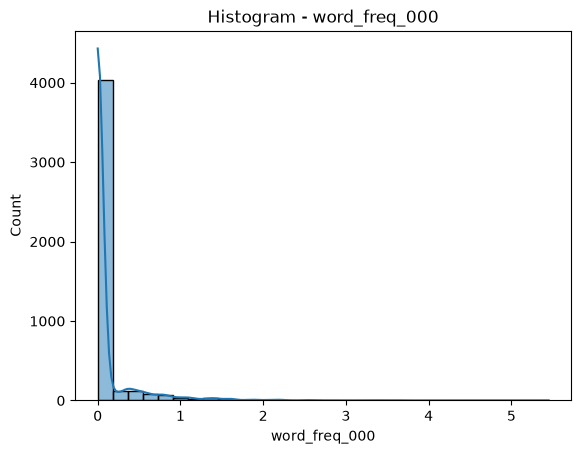

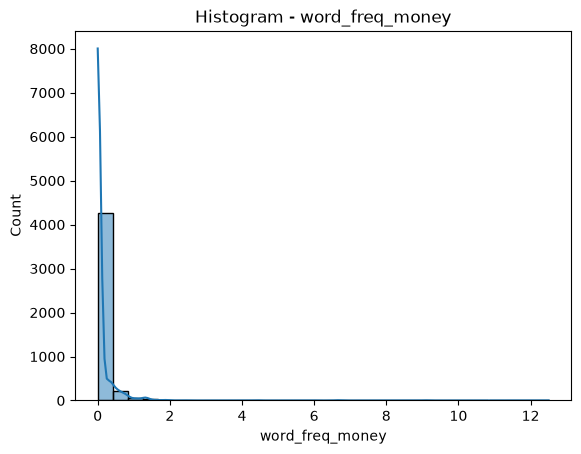

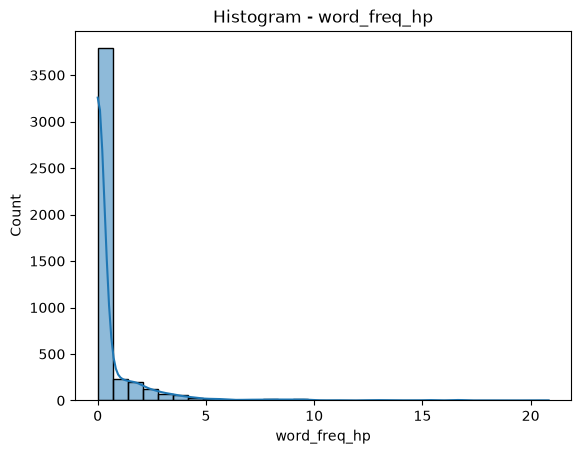

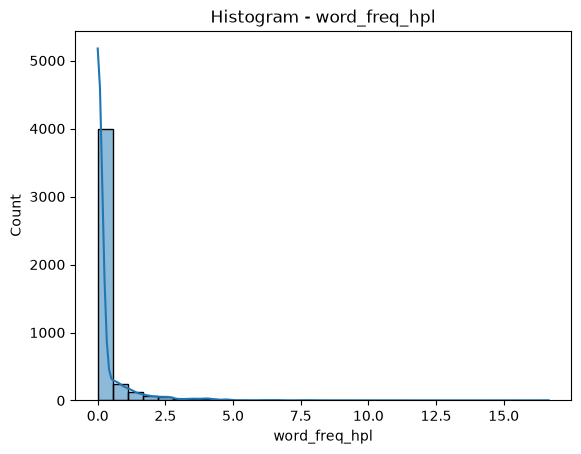

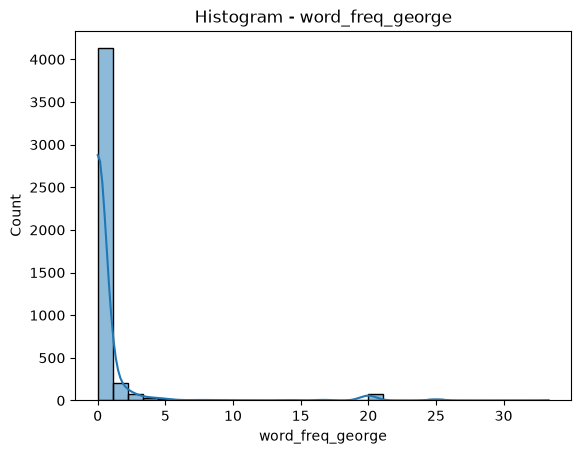

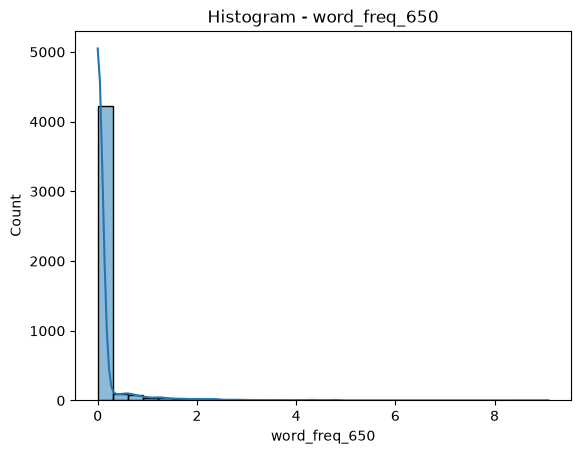

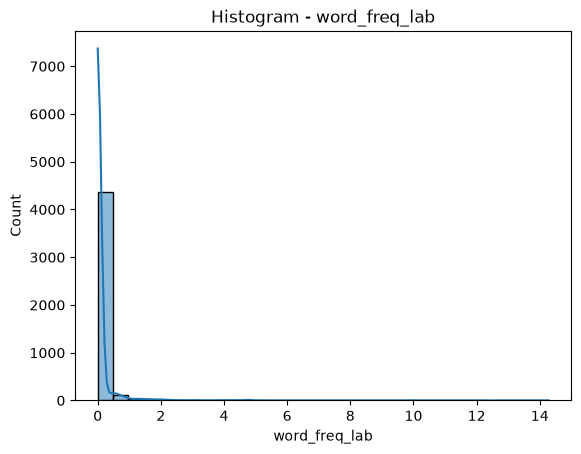

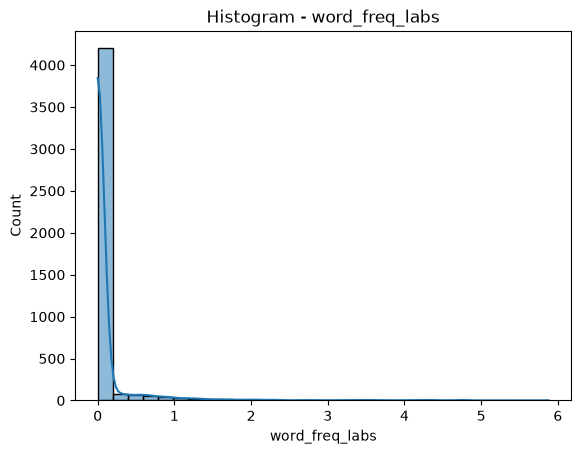

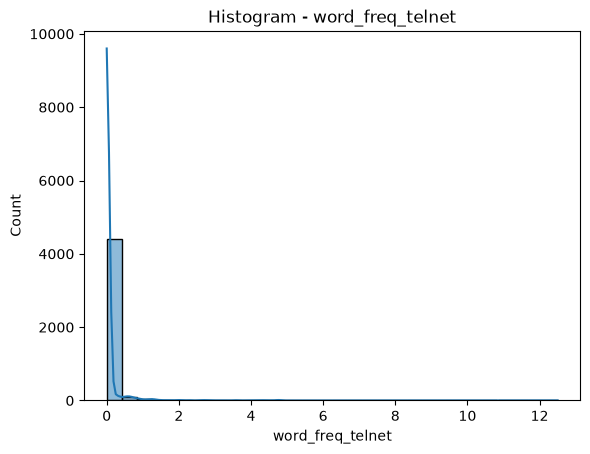

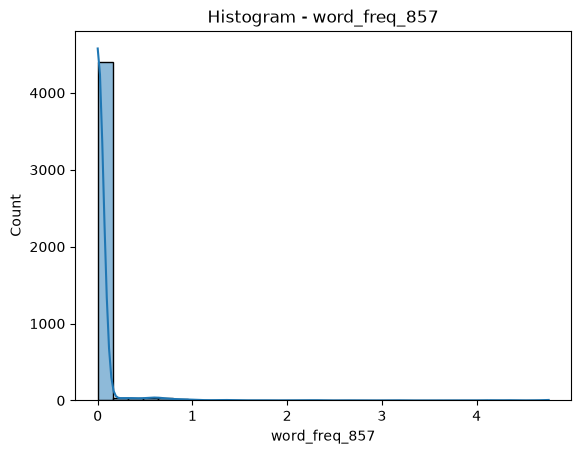

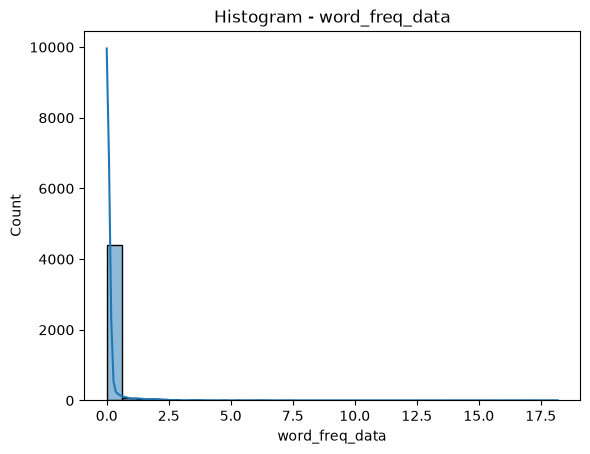

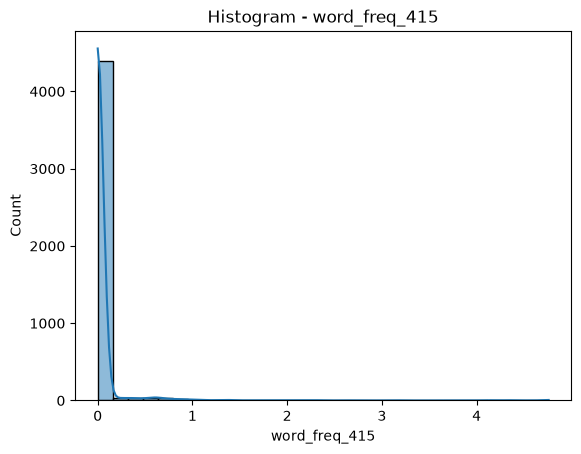

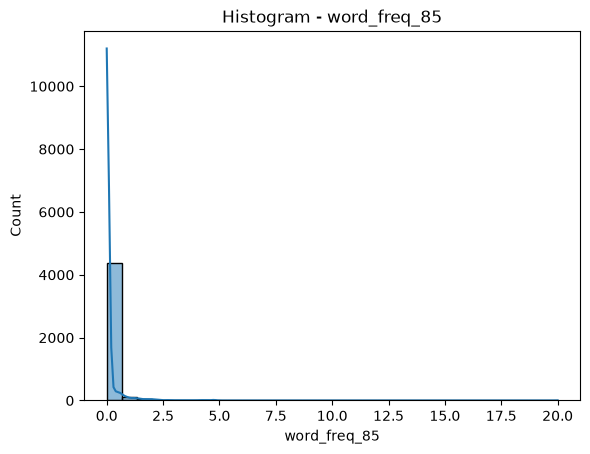

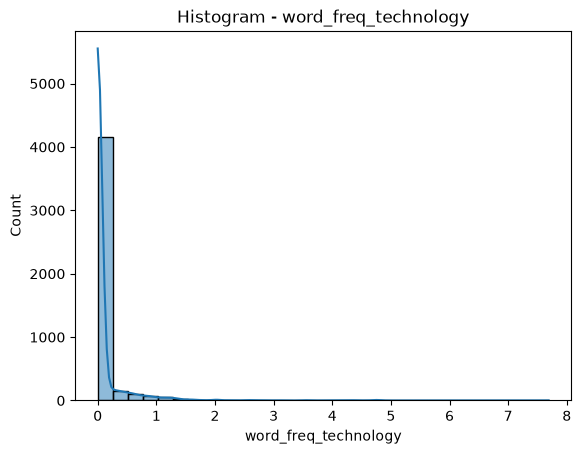

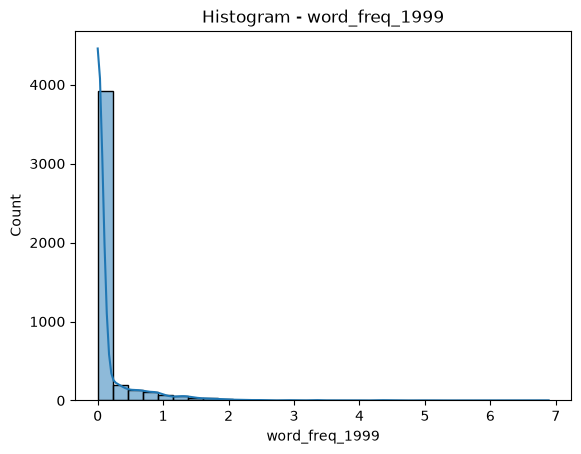

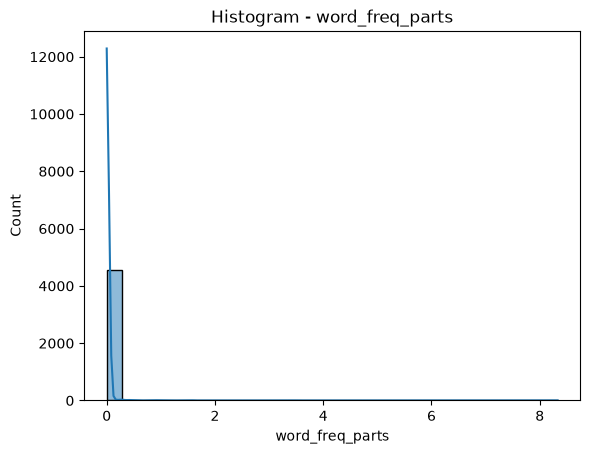

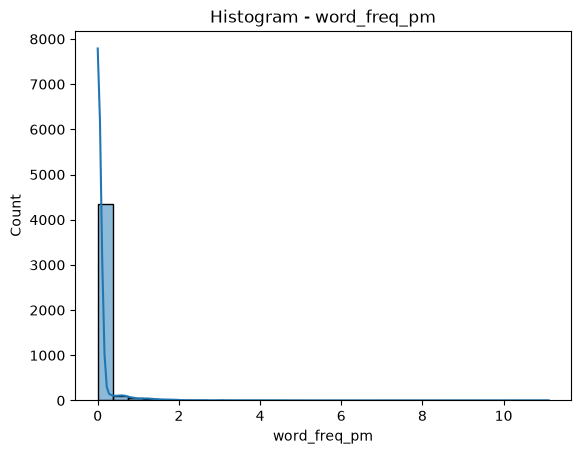

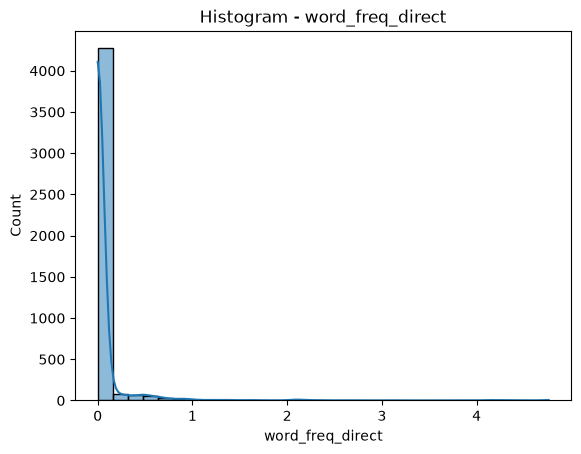

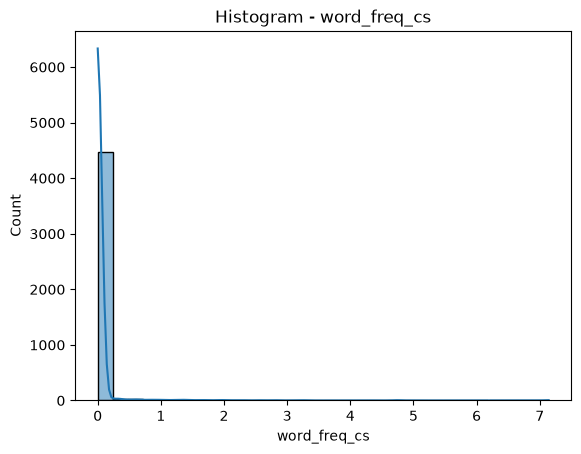

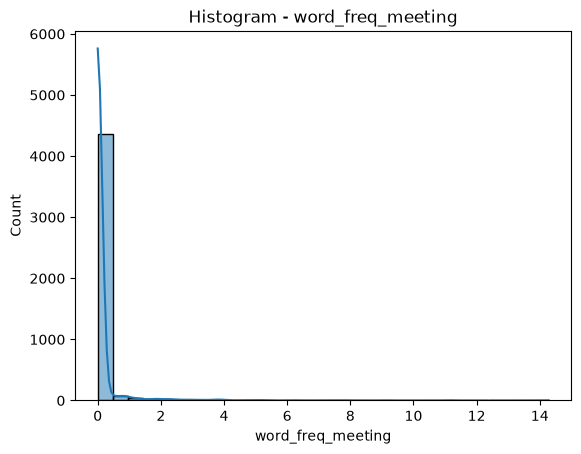

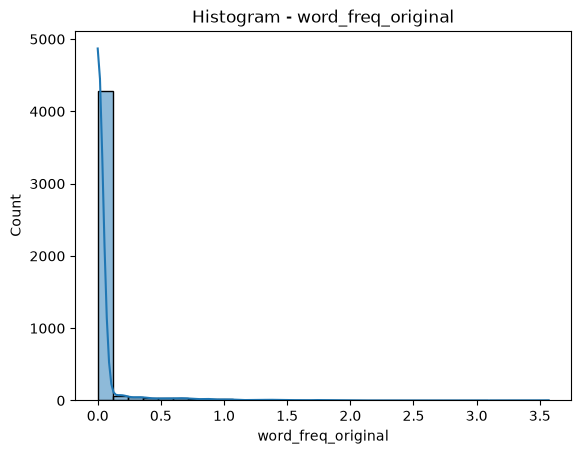

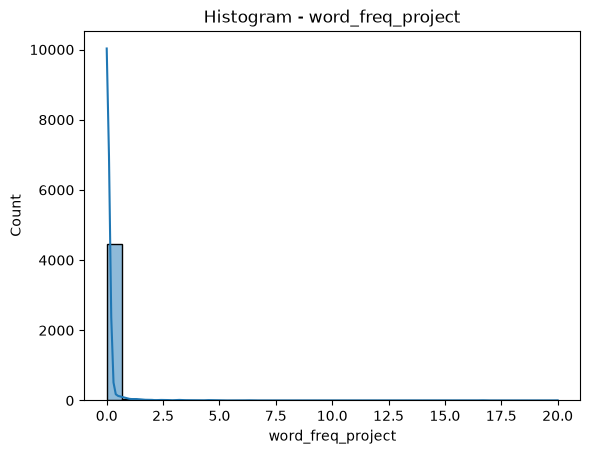

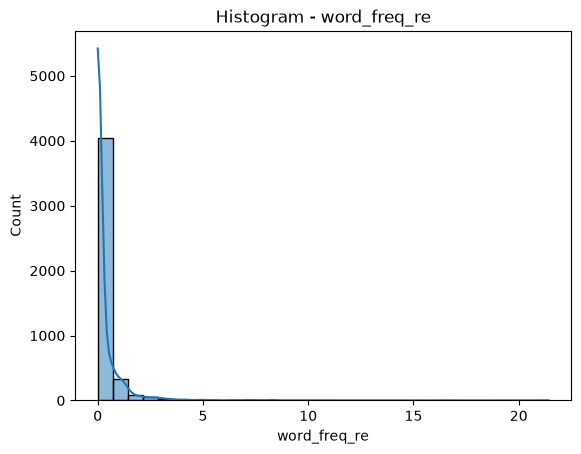

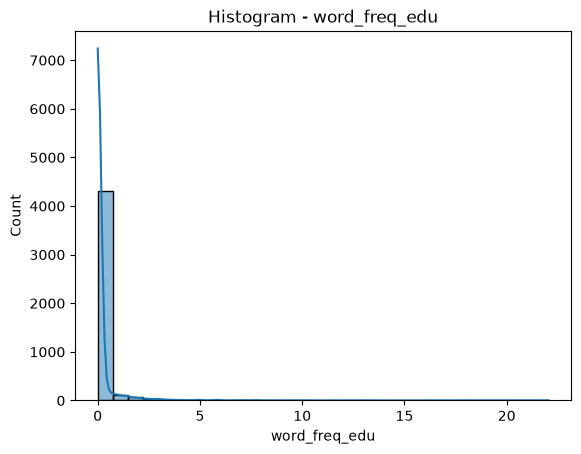

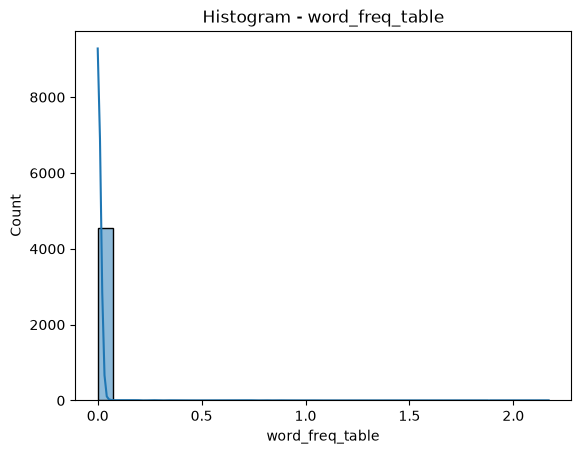

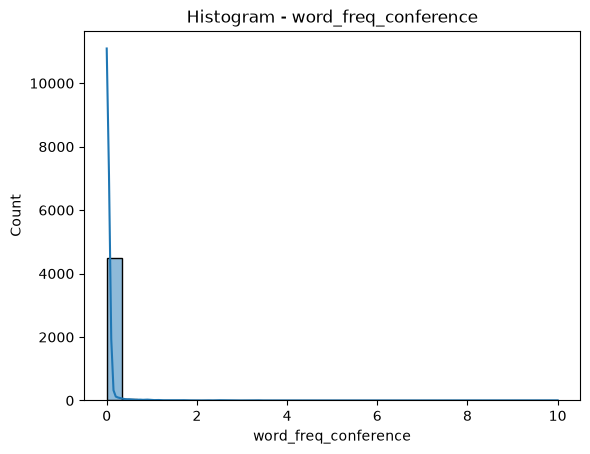

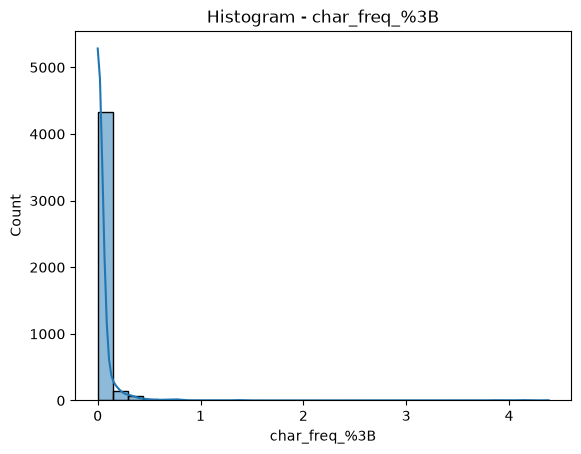

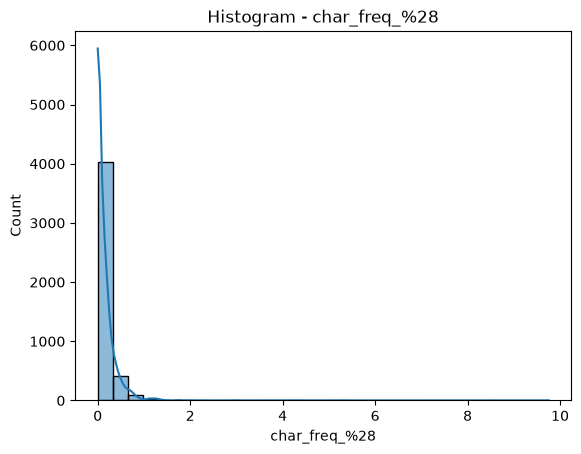

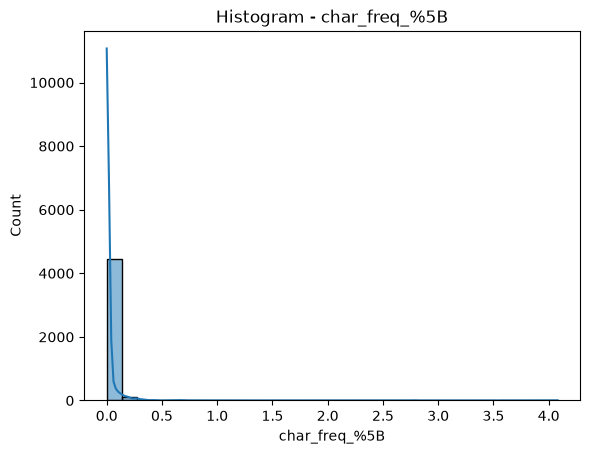

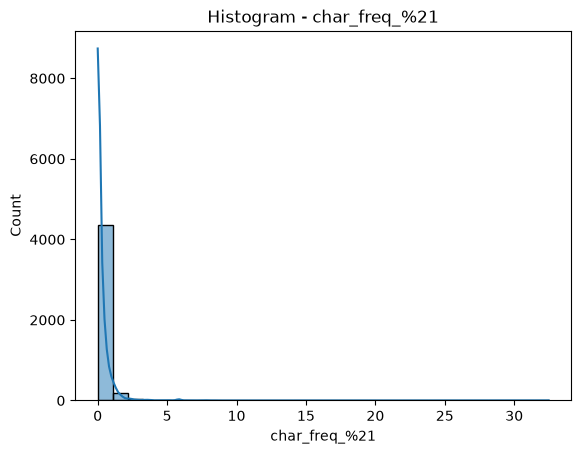

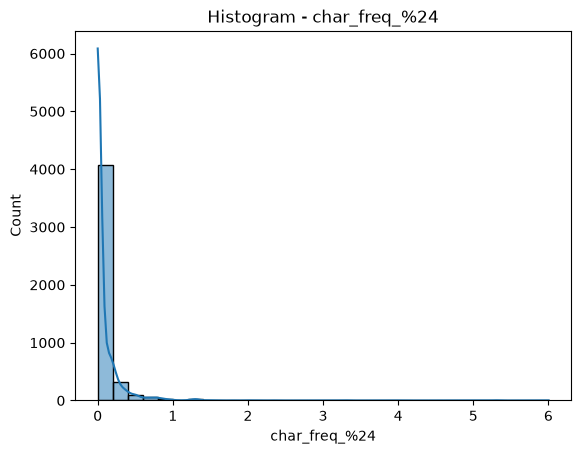

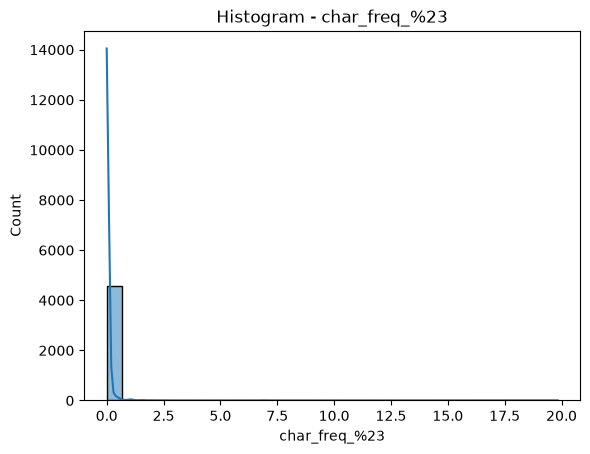

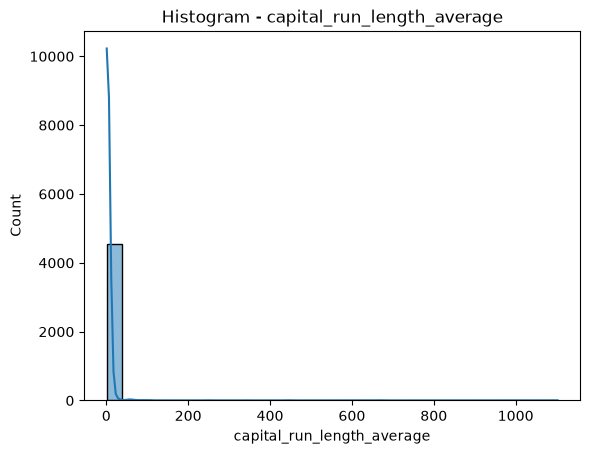

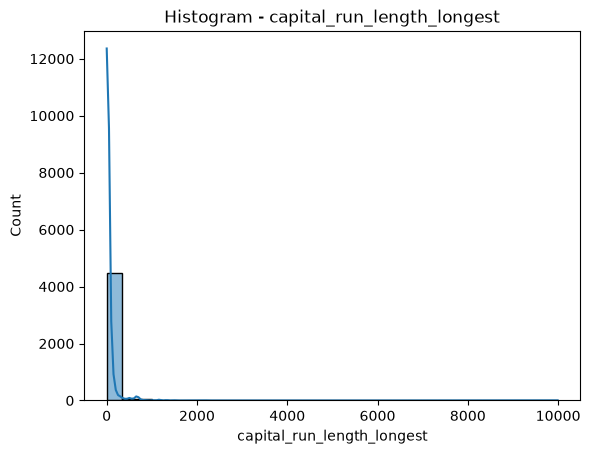

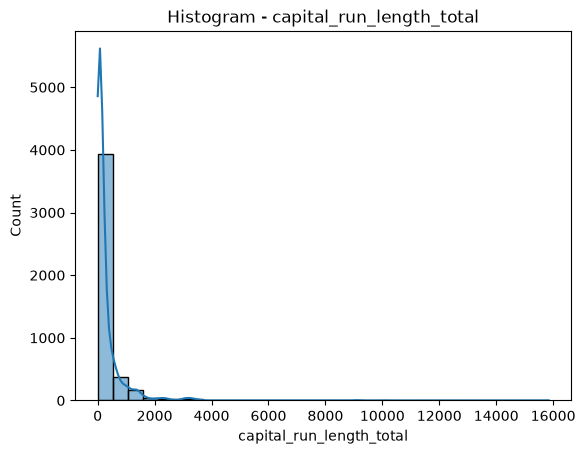

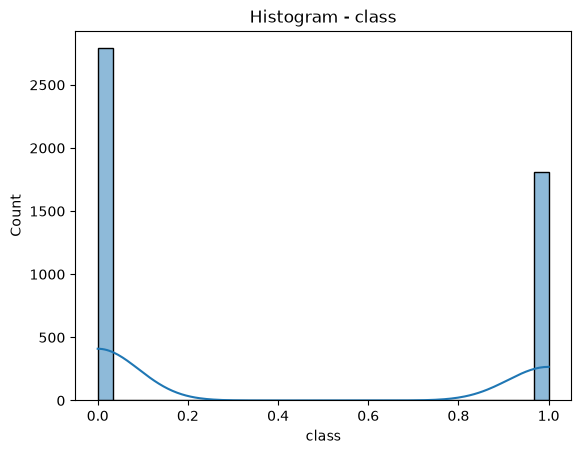

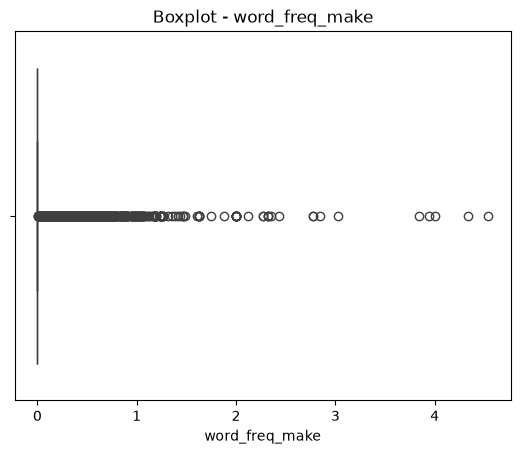

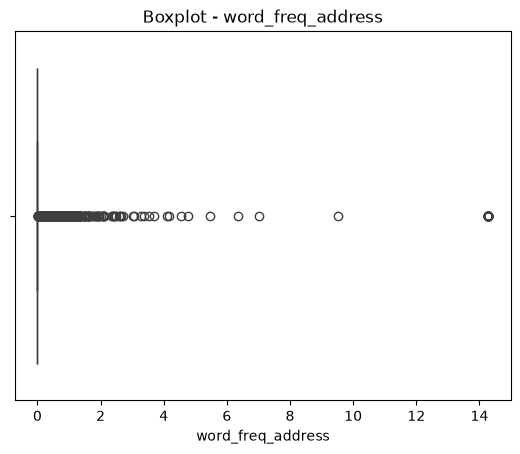

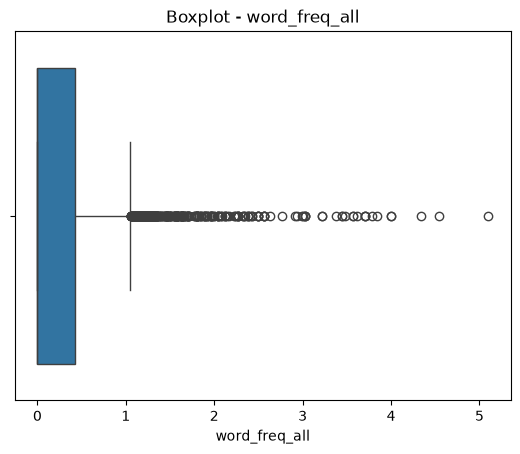

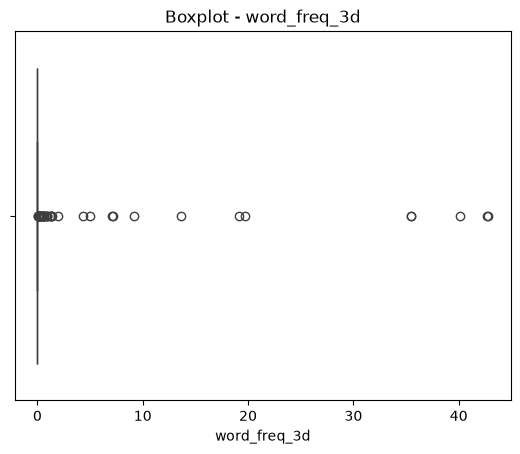

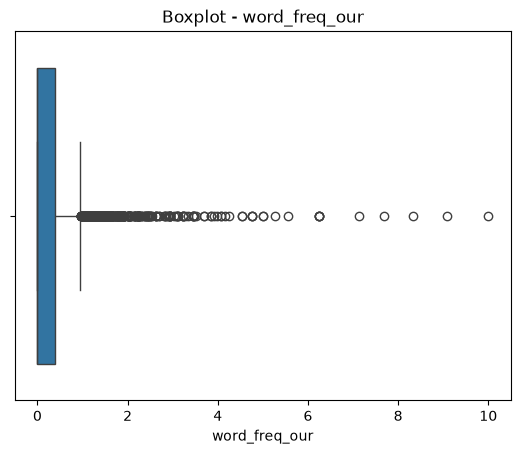

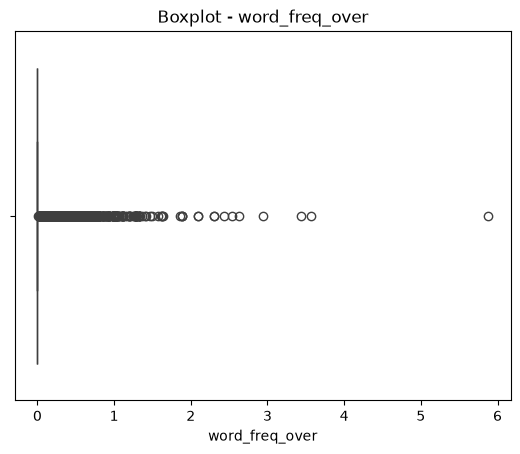

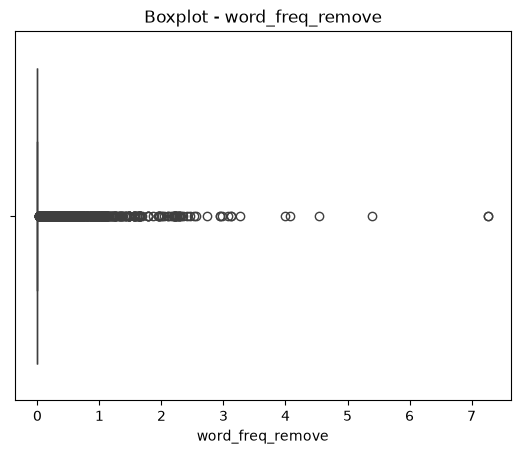

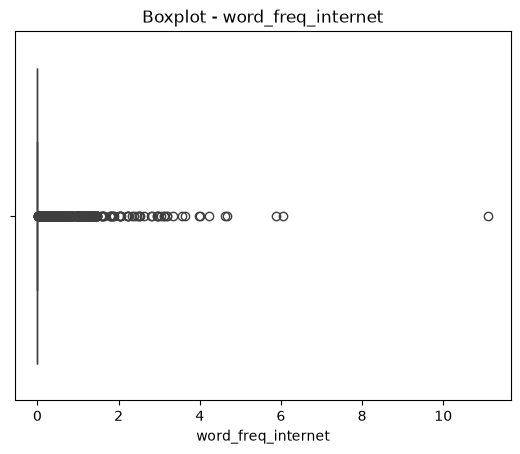

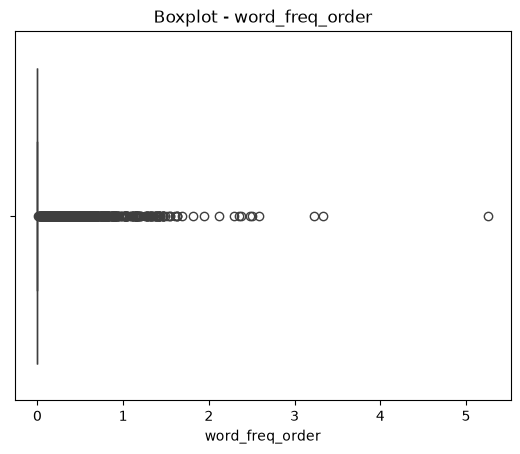

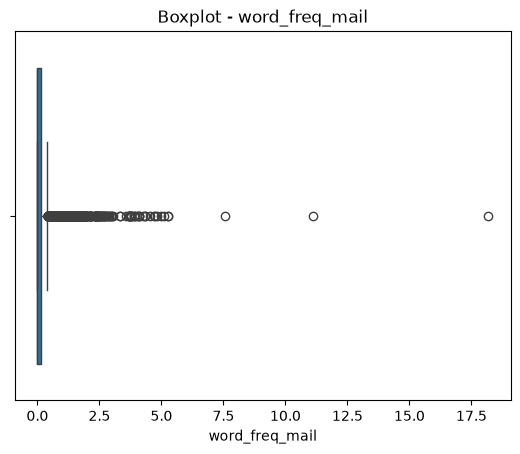

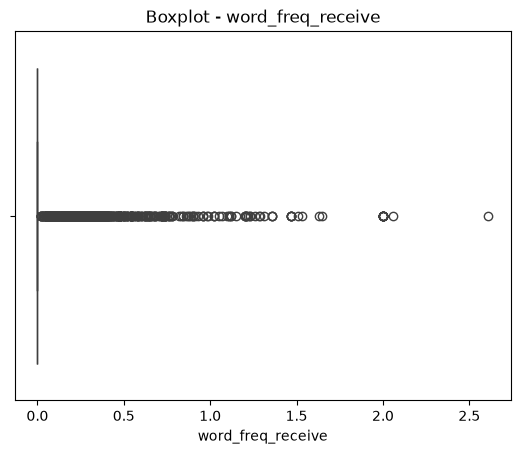

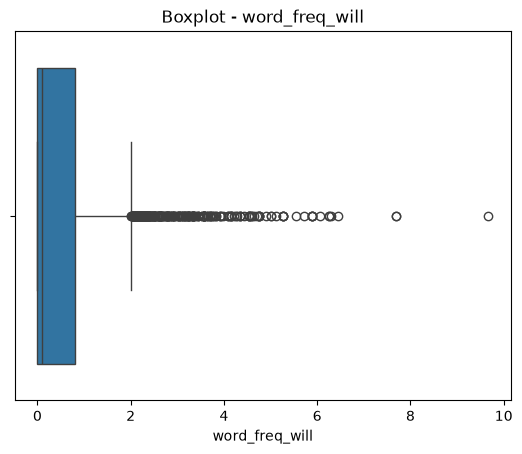

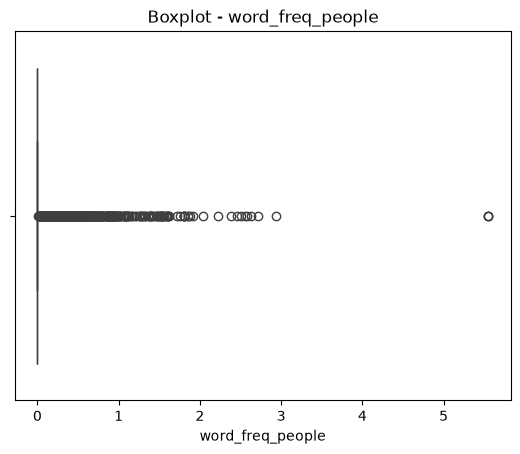

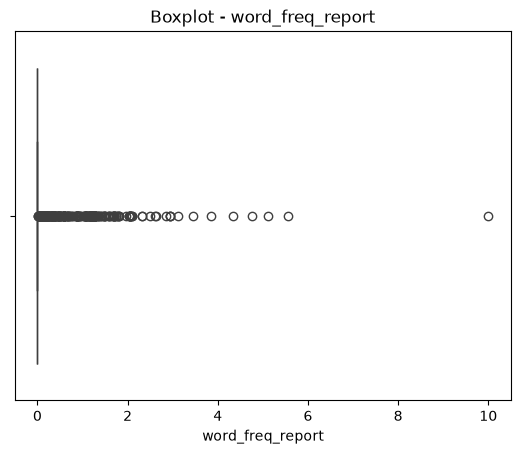

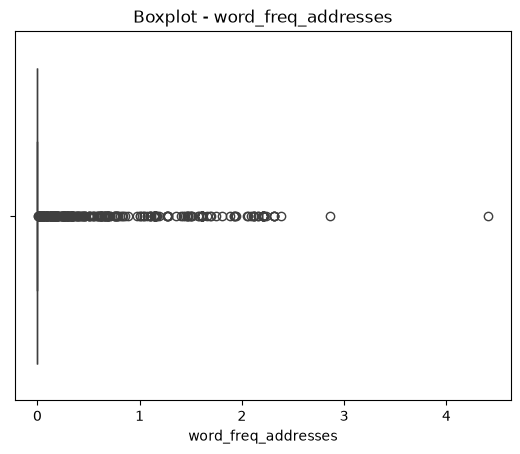

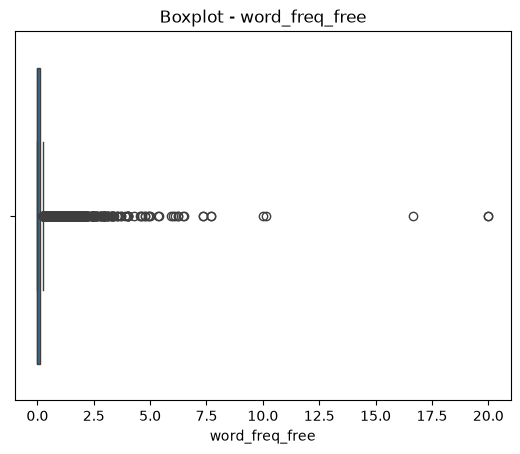

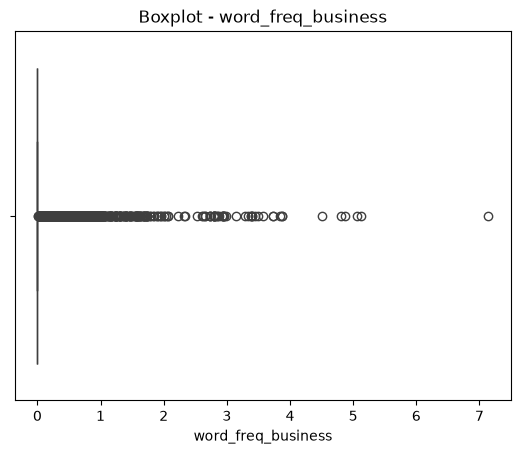

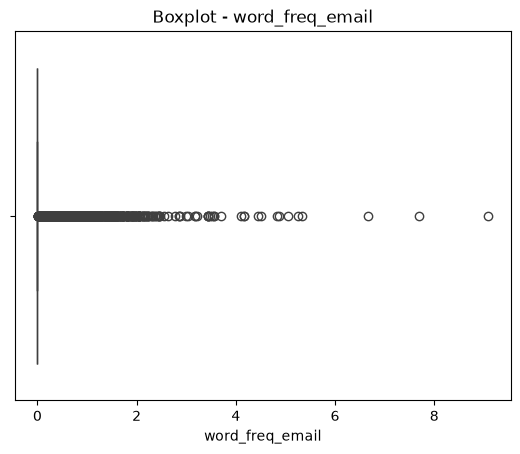

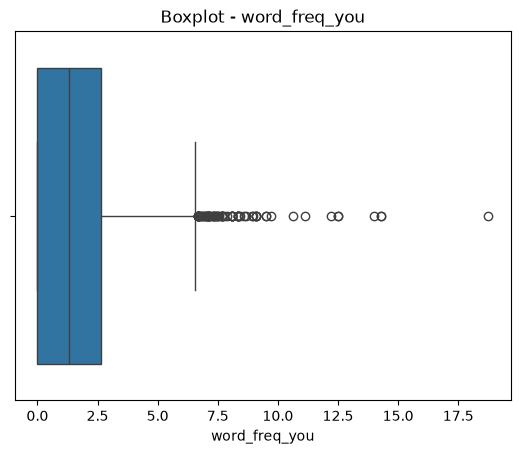

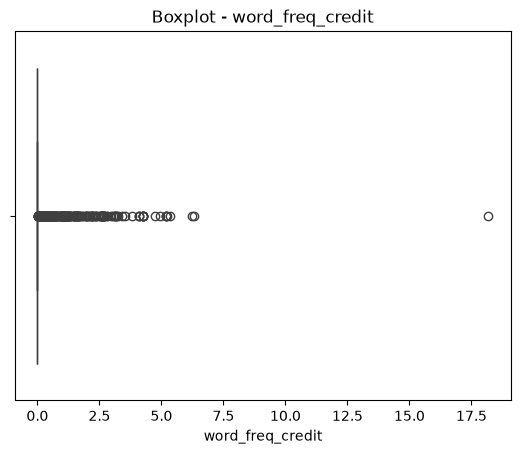

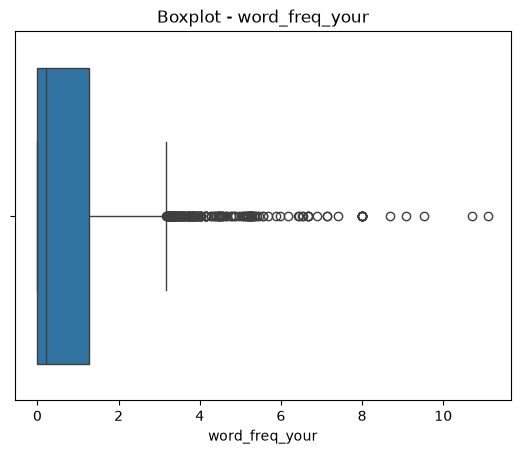

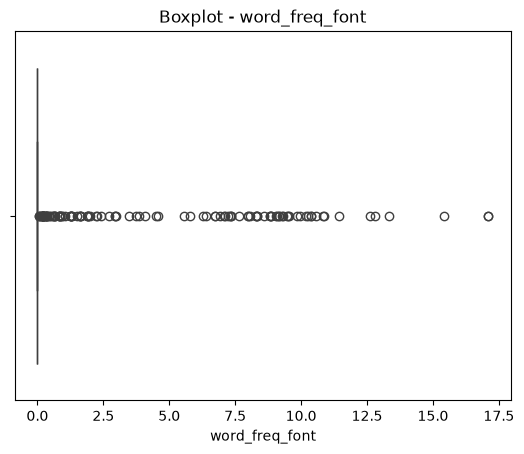

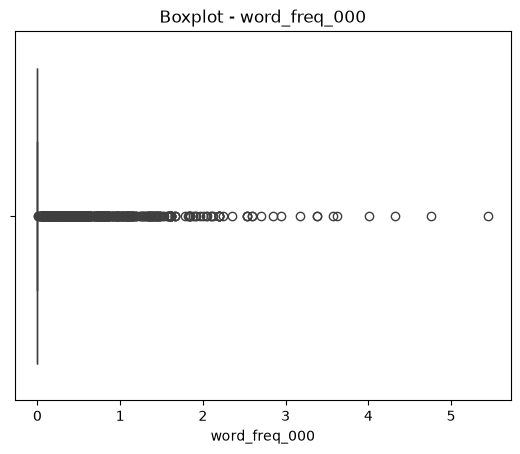

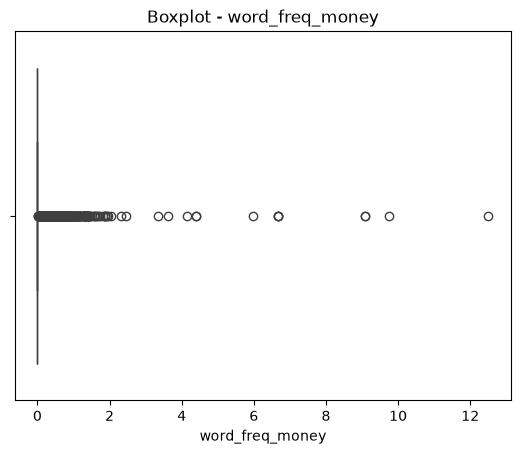

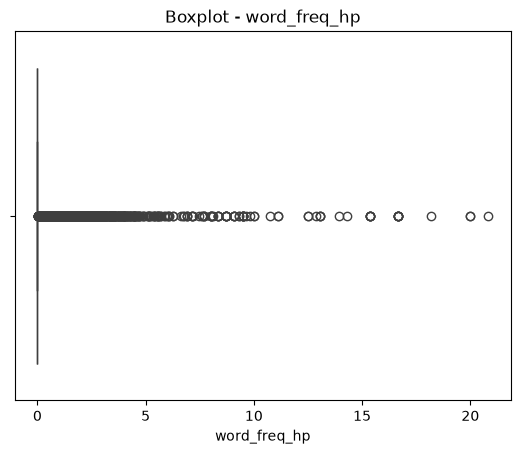

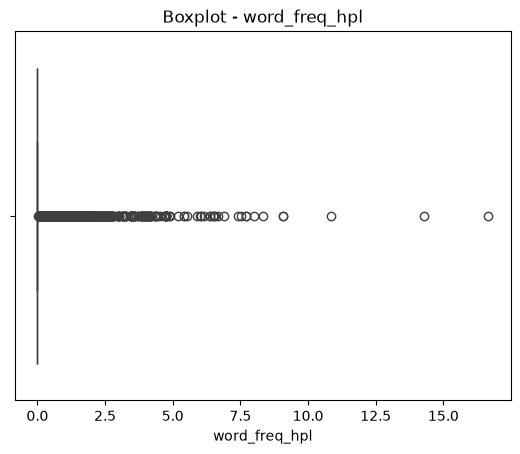

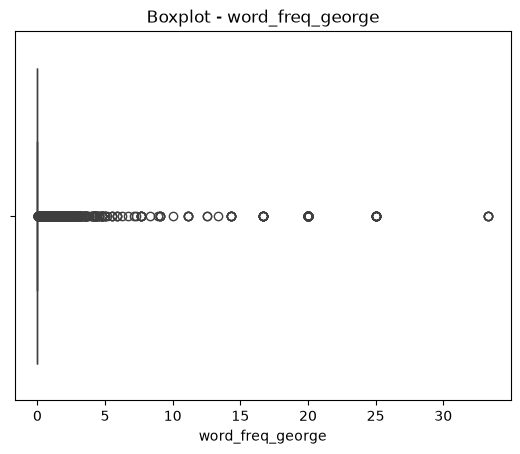

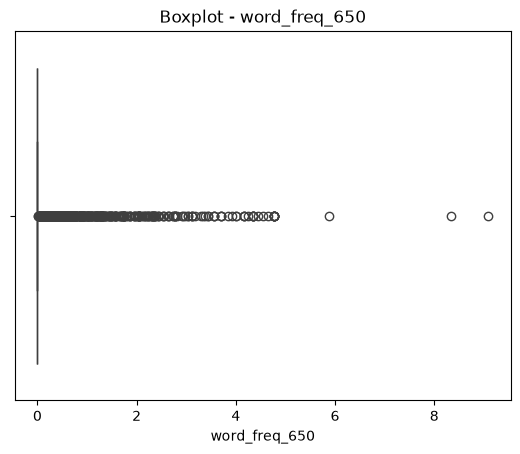

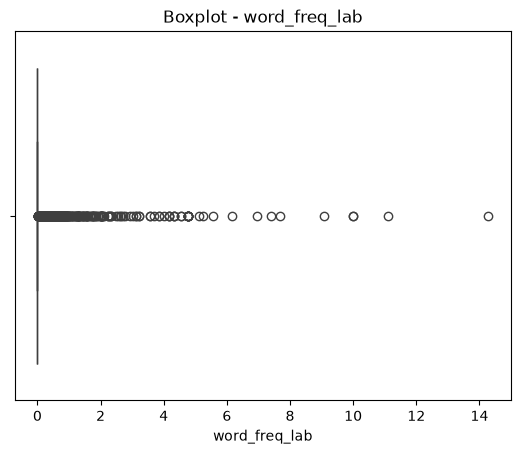

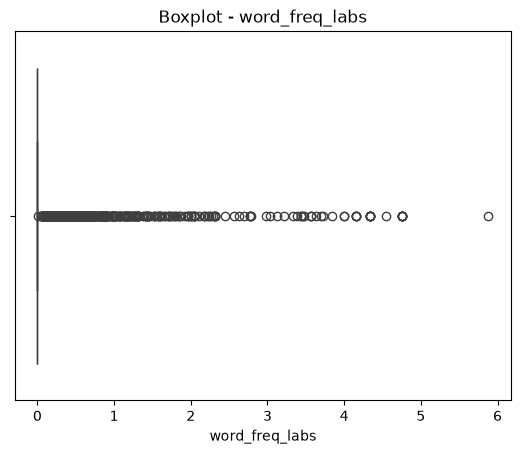

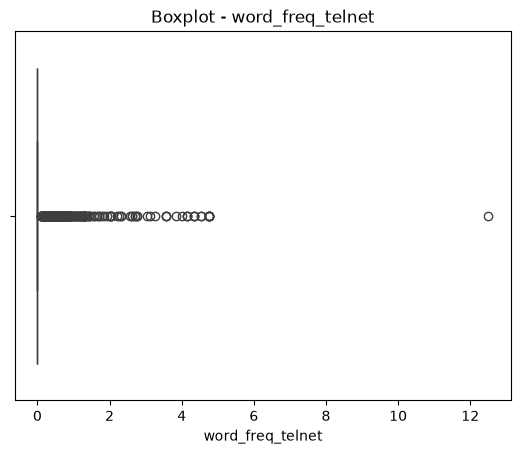

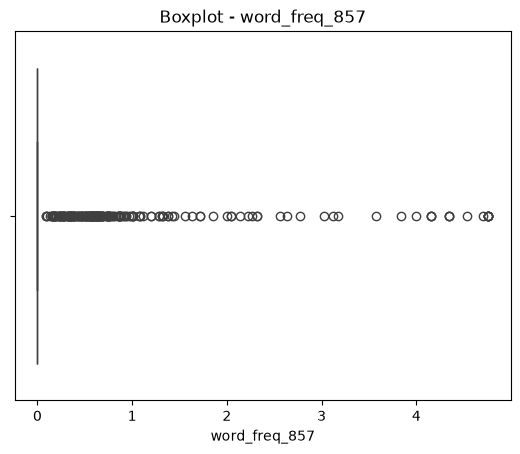

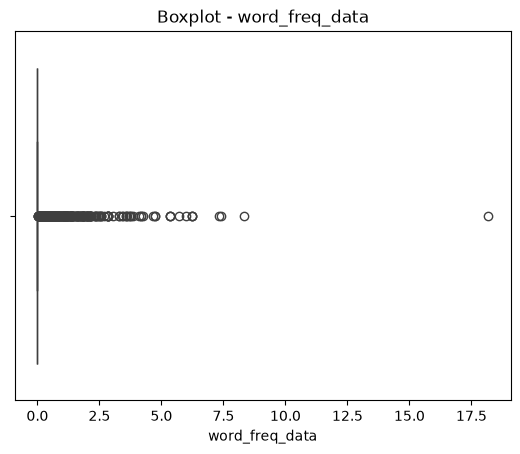

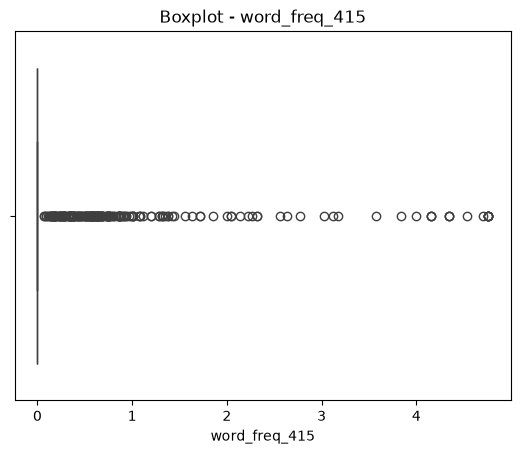

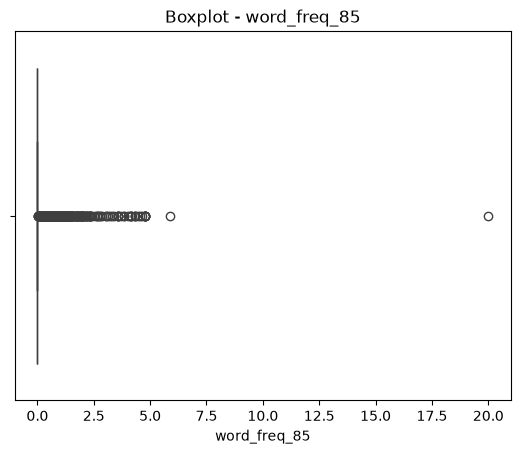

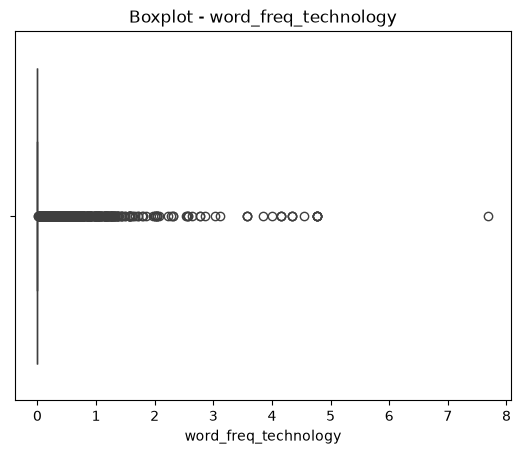

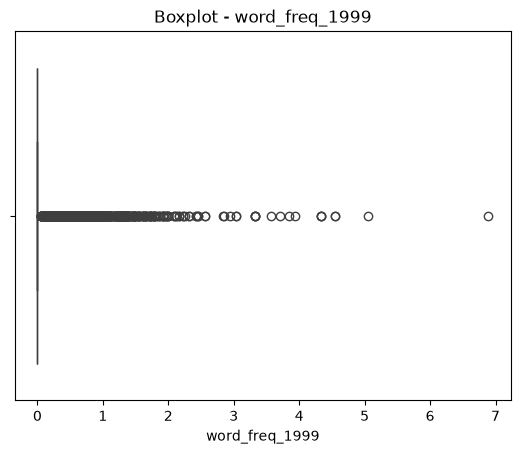

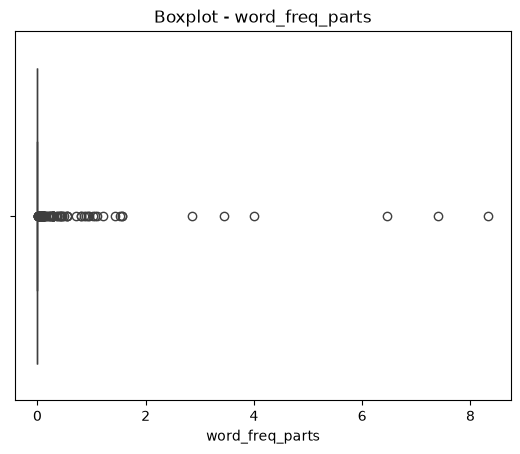

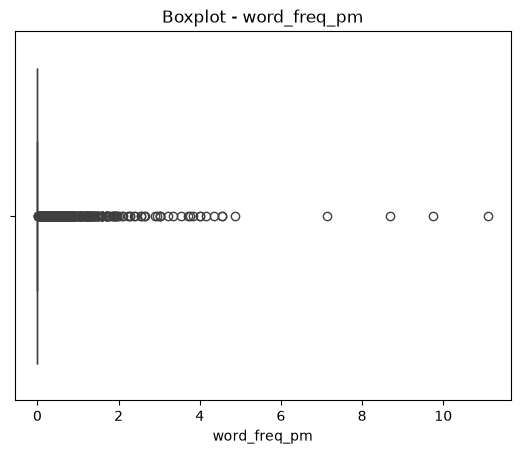

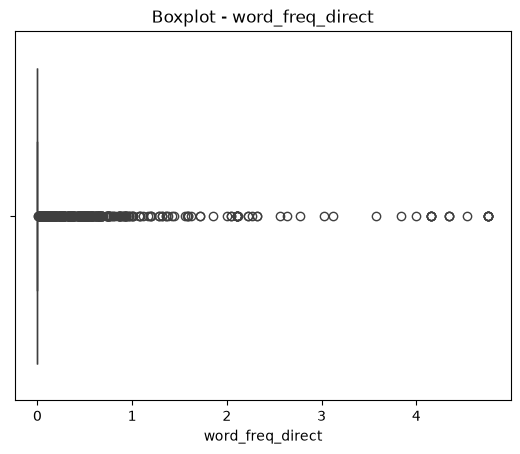

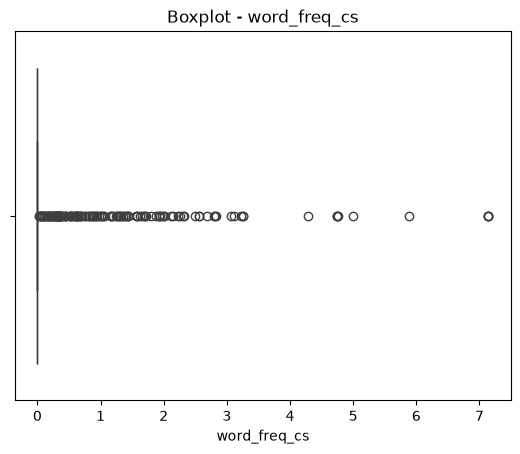

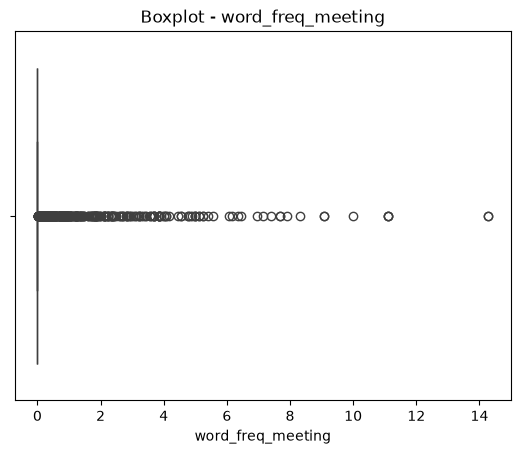

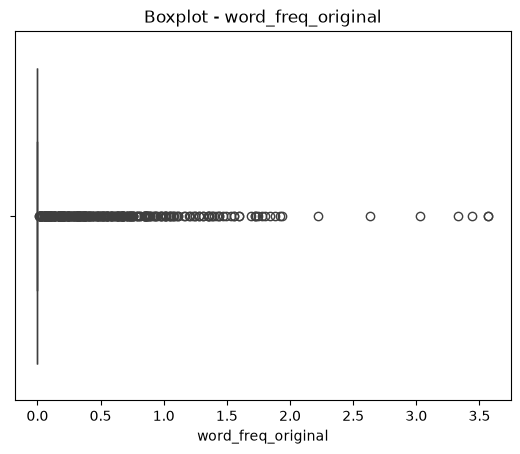

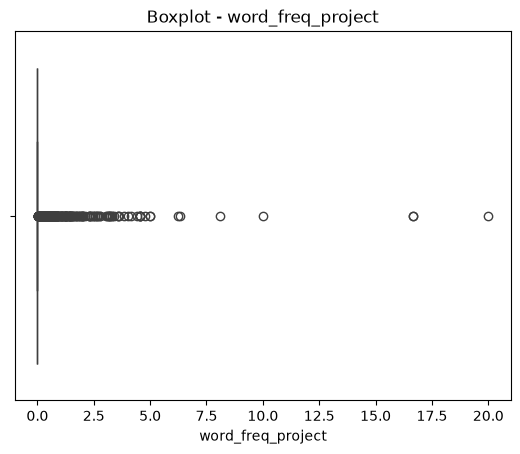

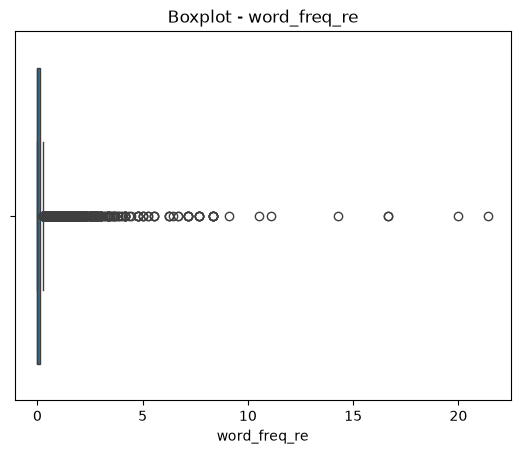

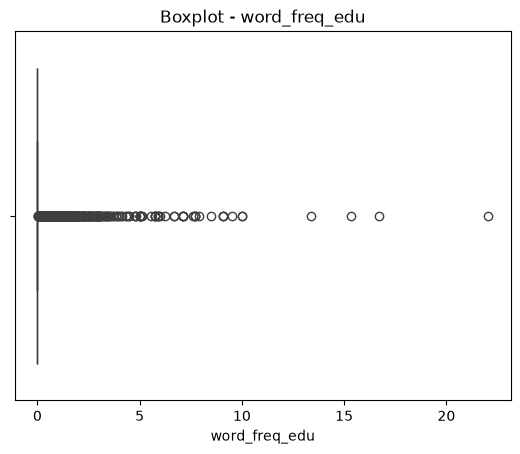

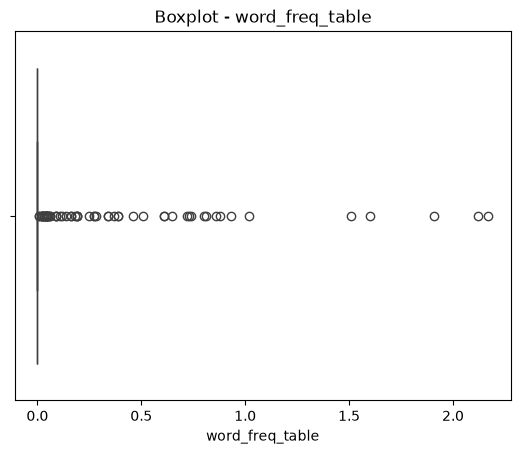

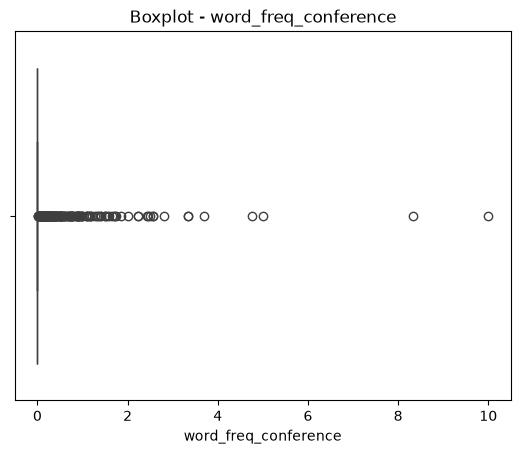

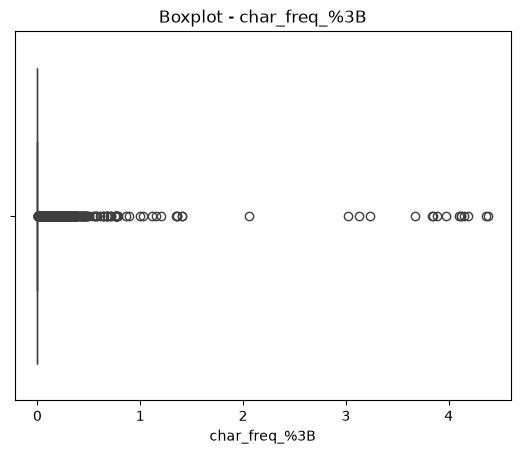

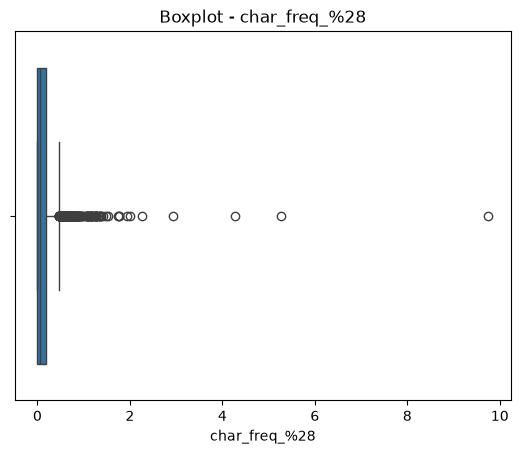

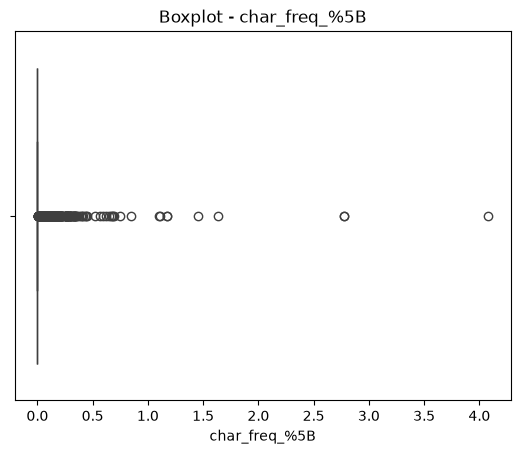

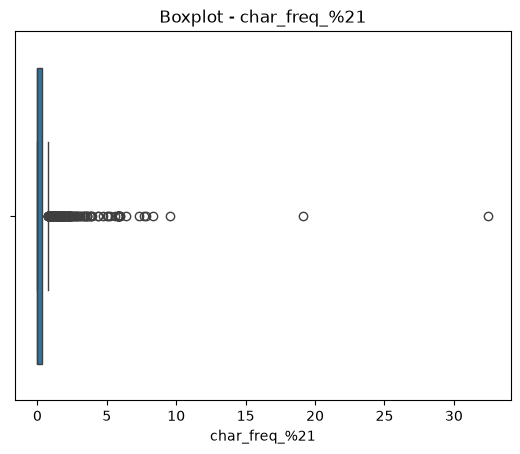

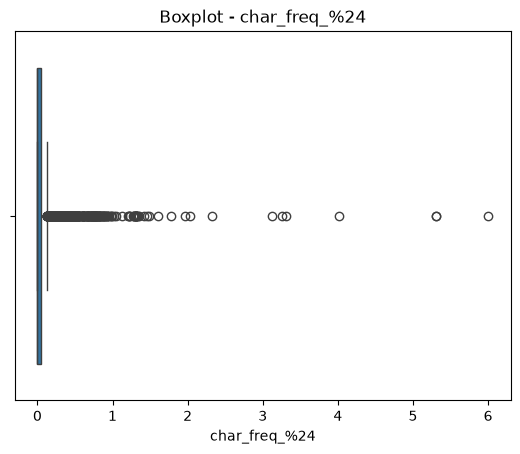

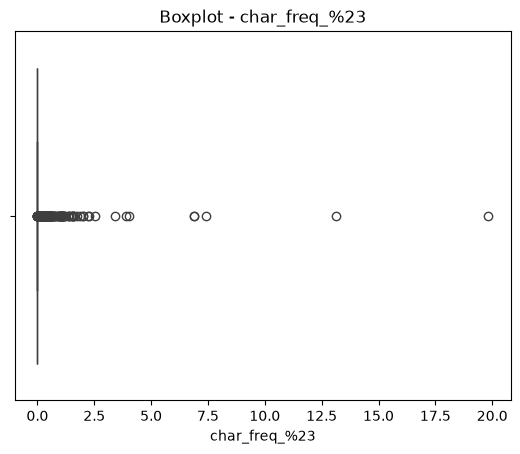

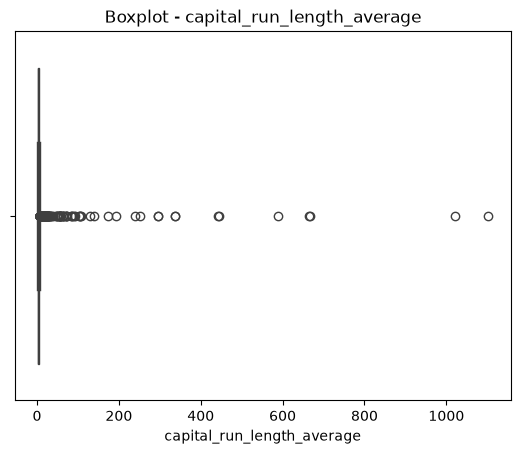

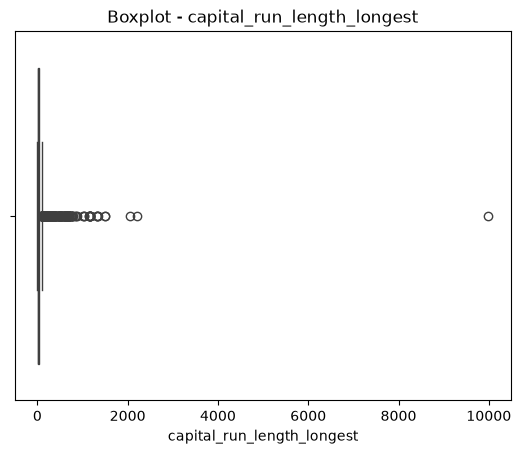

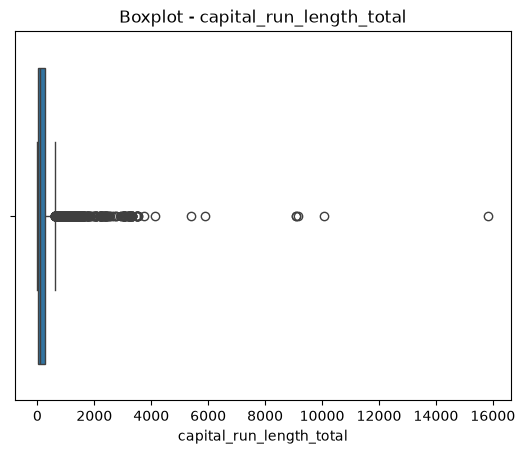

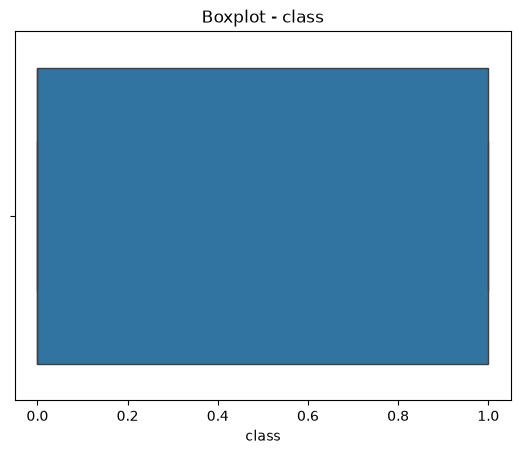


Outlier Count (IQR Method)
word_freq_make: 1053
word_freq_address: 898
word_freq_all: 338
word_freq_3d: 47
word_freq_our: 501
word_freq_over: 999
word_freq_remove: 807
word_freq_internet: 824
word_freq_order: 773
word_freq_mail: 852
word_freq_receive: 709
word_freq_will: 270
word_freq_people: 852
word_freq_report: 357
word_freq_addresses: 336
word_freq_free: 957
word_freq_business: 963
word_freq_email: 1038
word_freq_you: 75
word_freq_credit: 424
word_freq_your: 229
word_freq_font: 117
word_freq_000: 679
word_freq_money: 735
word_freq_hp: 1090
word_freq_hpl: 811
word_freq_george: 780
word_freq_650: 463
word_freq_lab: 372
word_freq_labs: 469
word_freq_telnet: 293
word_freq_857: 205
word_freq_data: 405
word_freq_415: 215
word_freq_85: 485
word_freq_technology: 599
word_freq_1999: 829
word_freq_parts: 83
word_freq_pm: 384
word_freq_direct: 453
word_freq_cs: 148
word_freq_meeting: 341
word_freq_original: 375
word_freq_project: 327
word_freq_re: 1001
word_freq_edu: 517
word_freq_table: 63


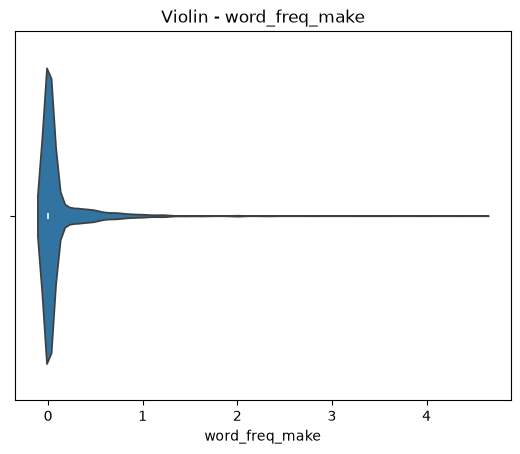

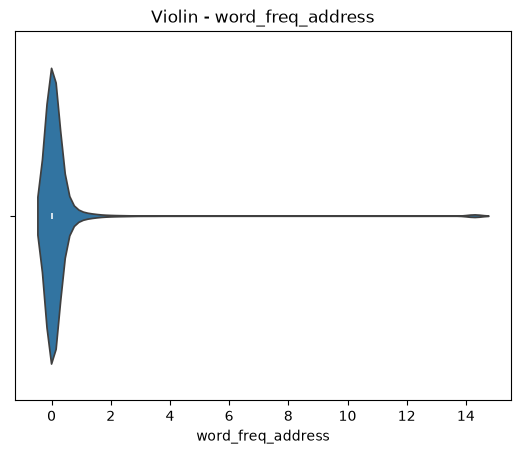

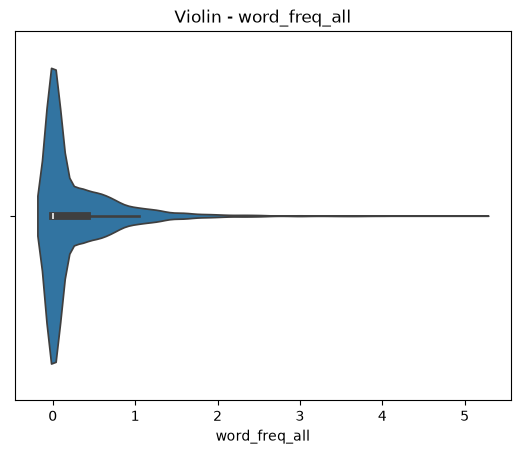

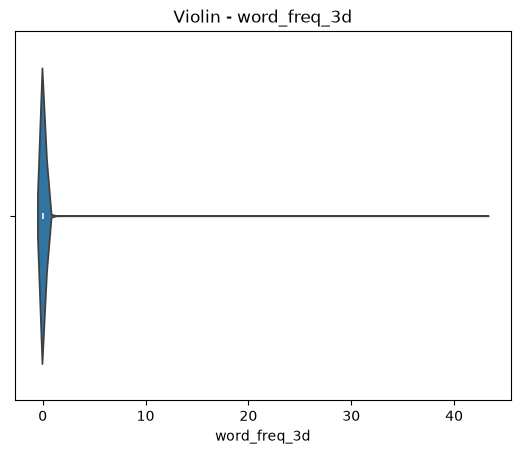

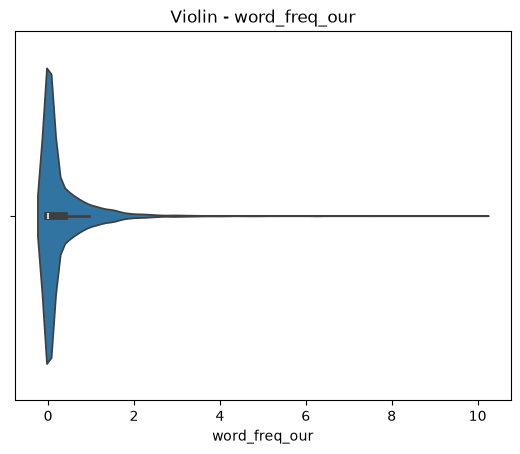

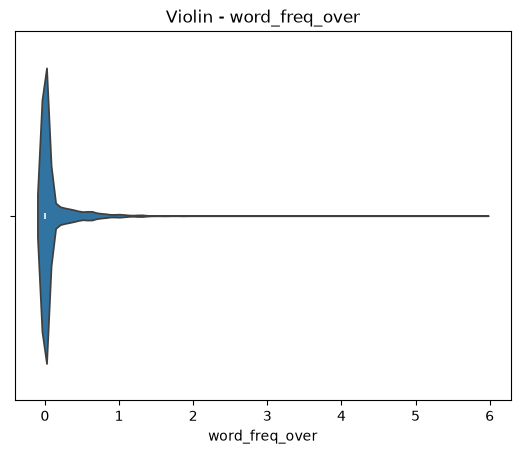

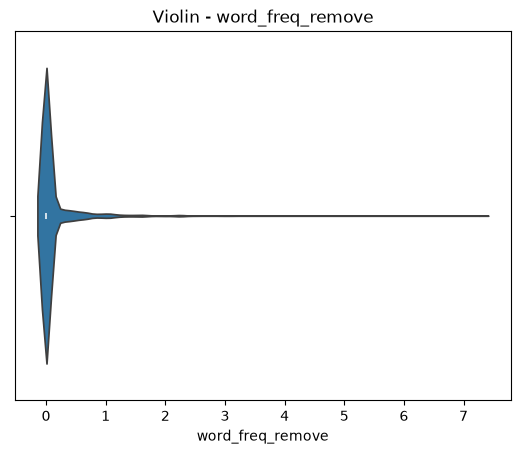

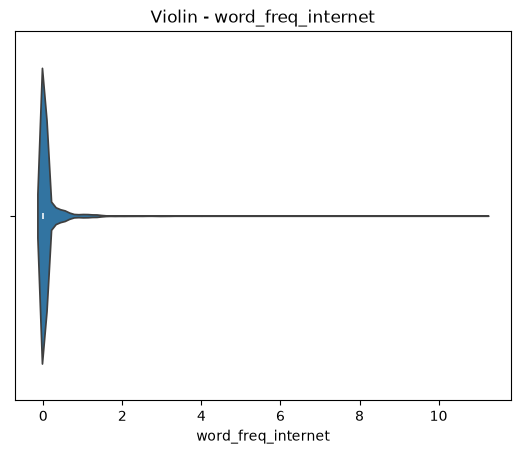

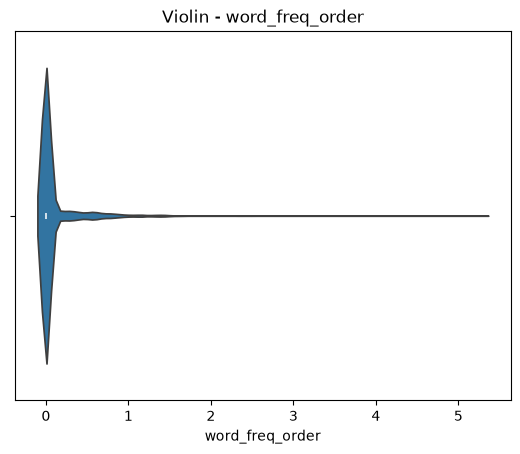

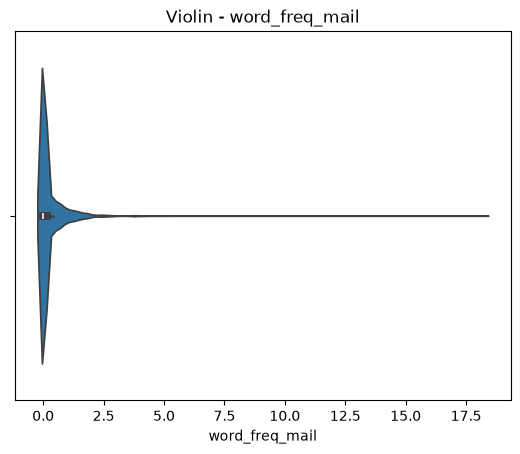

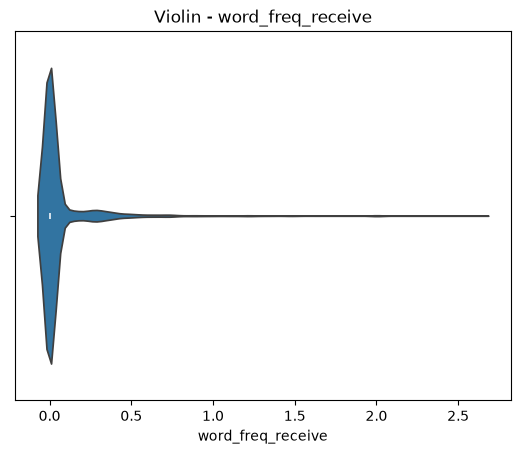

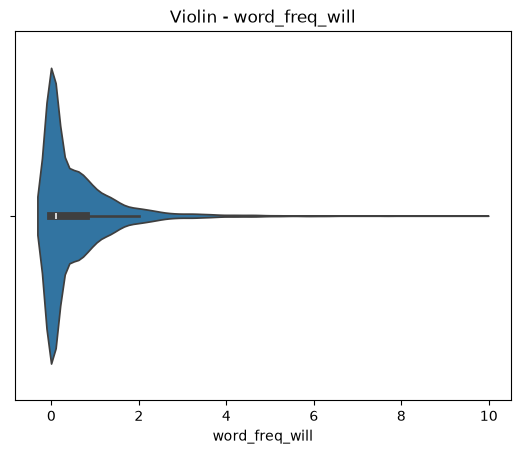

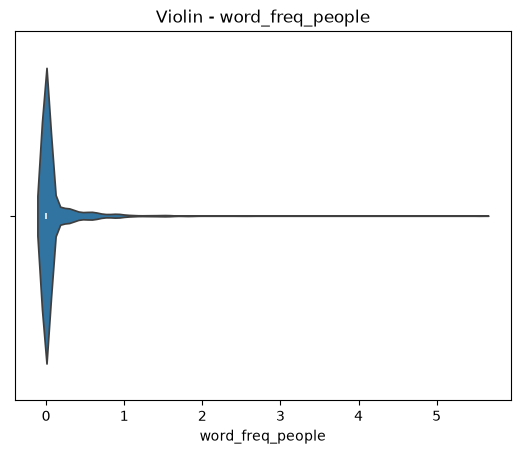

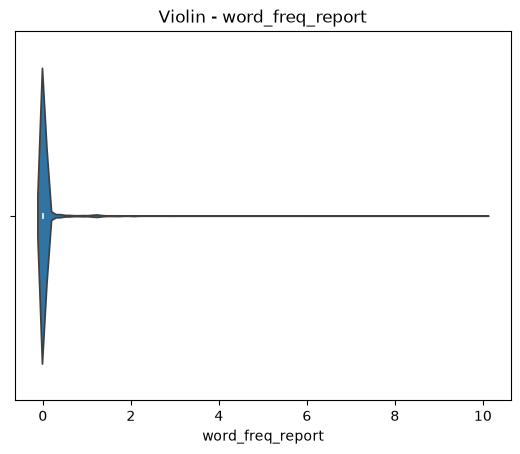

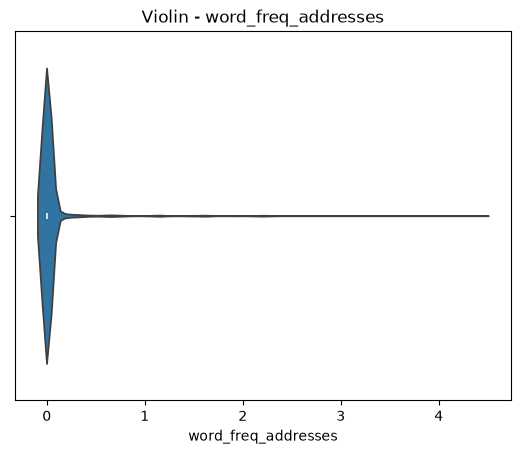

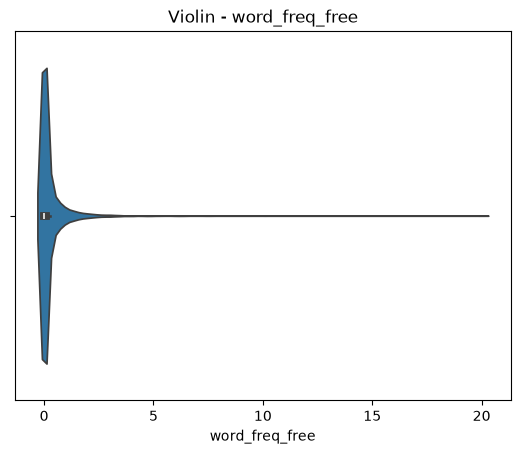

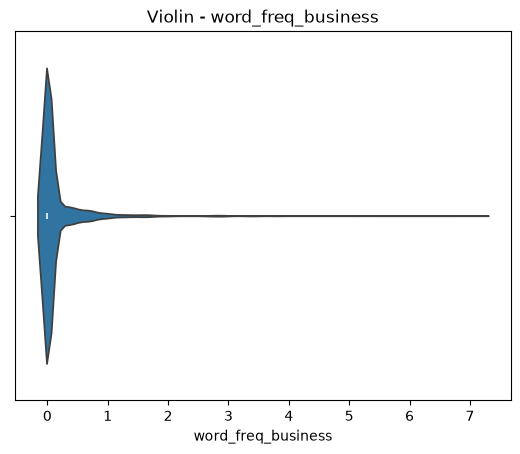

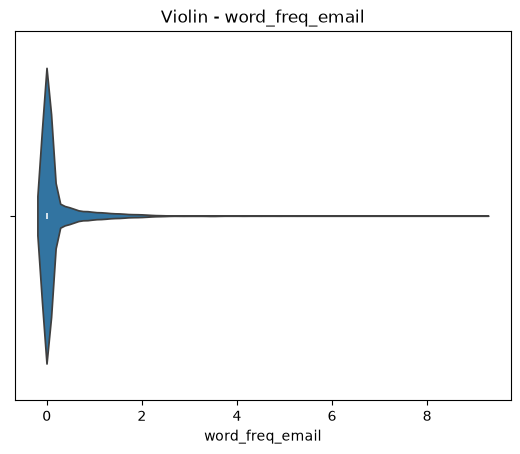

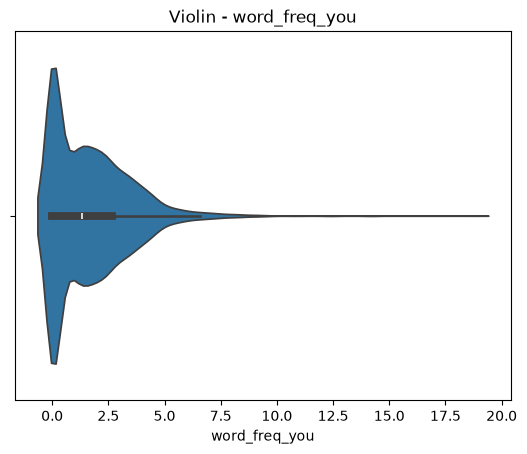

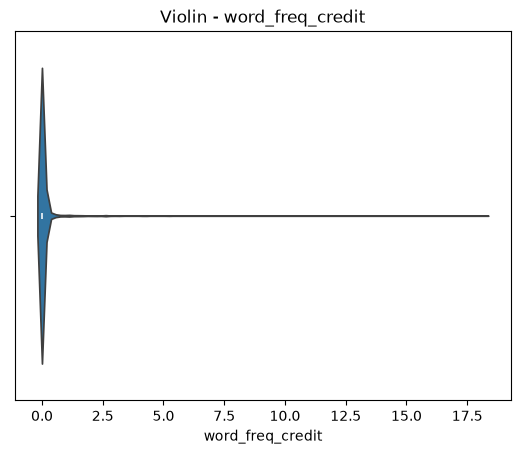

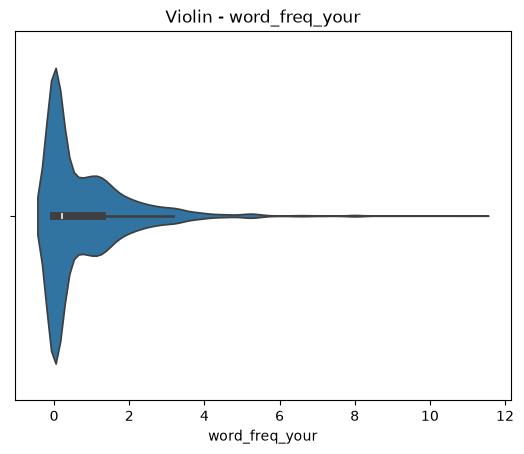

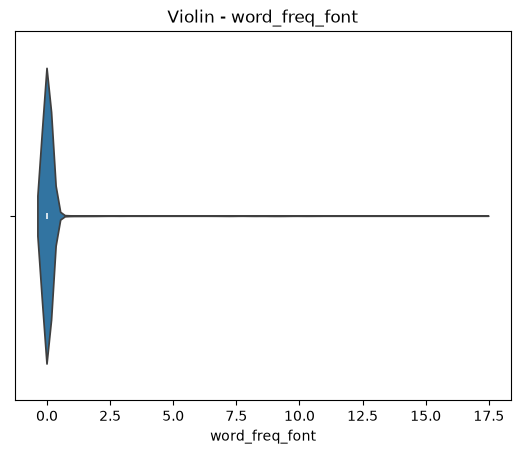

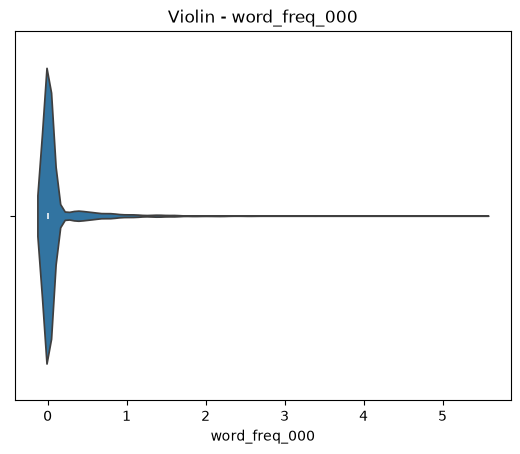

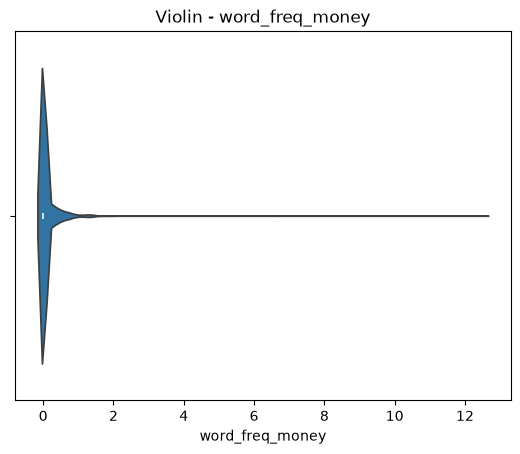

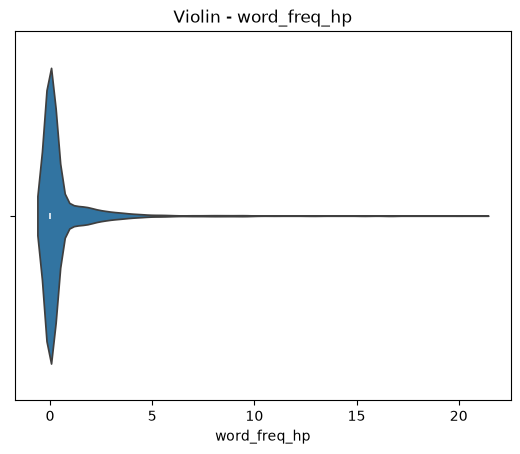

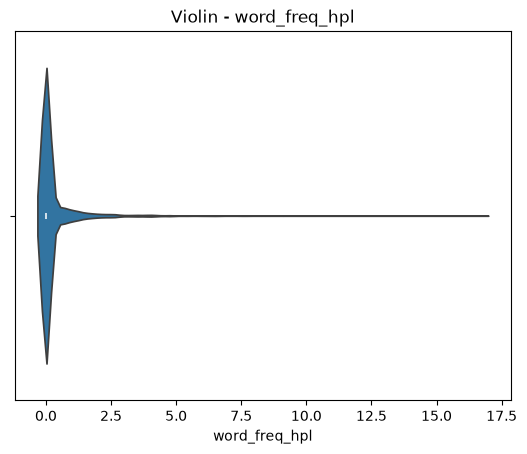

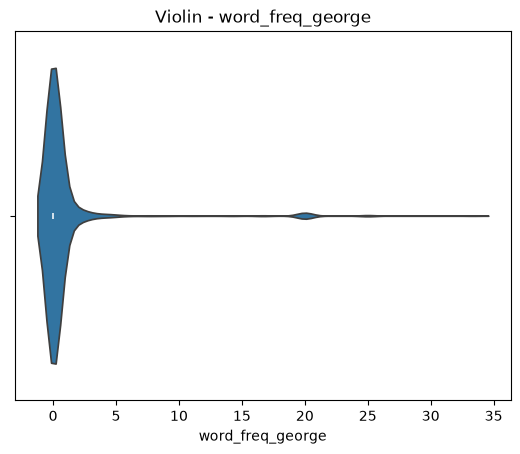

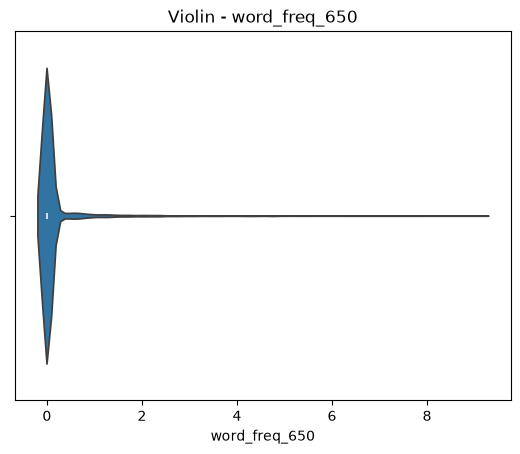

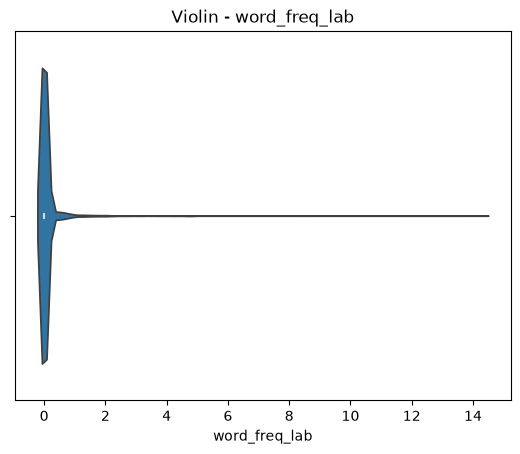

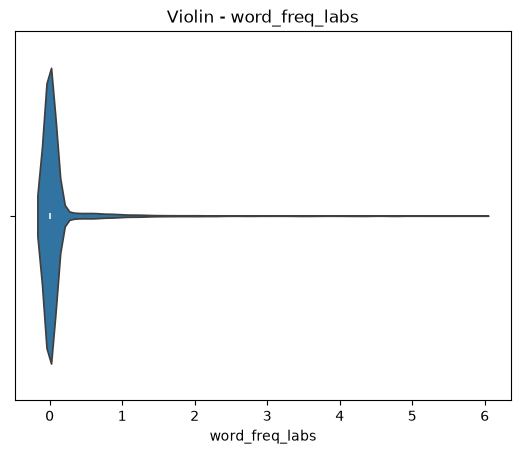

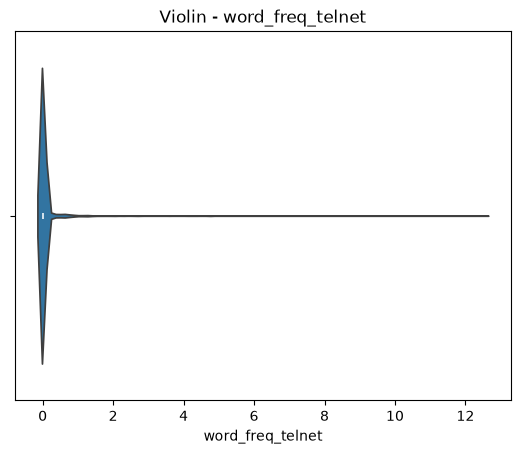

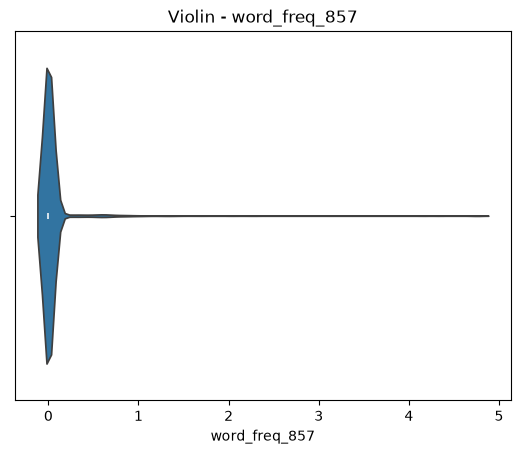

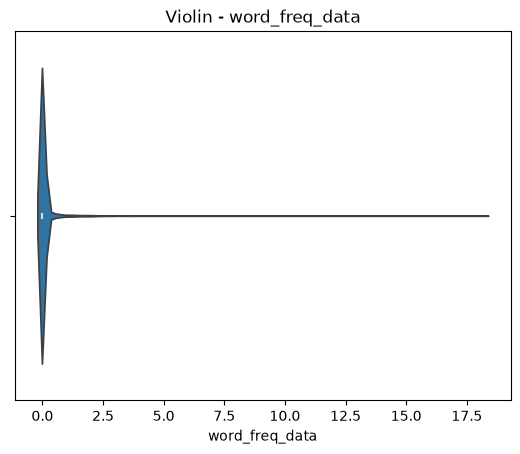

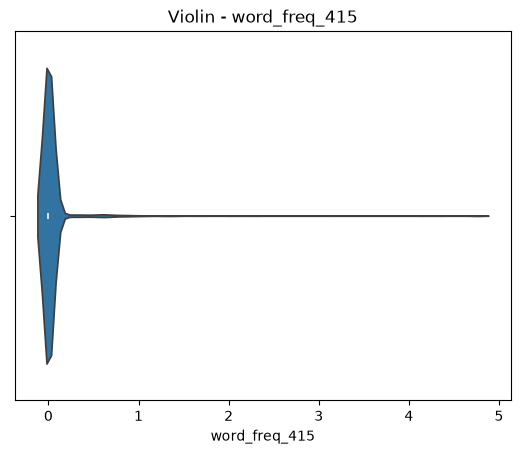

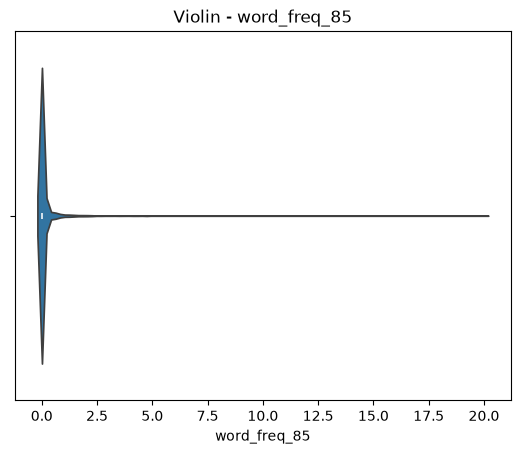

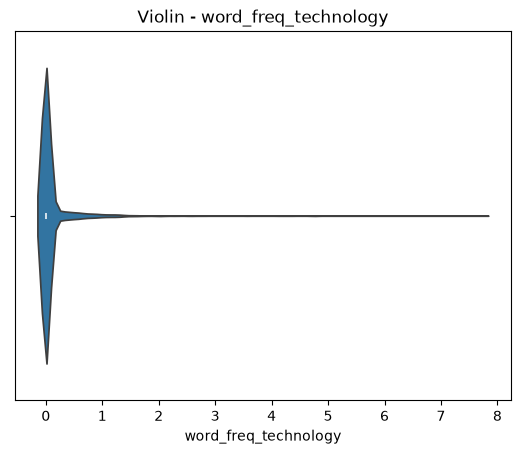

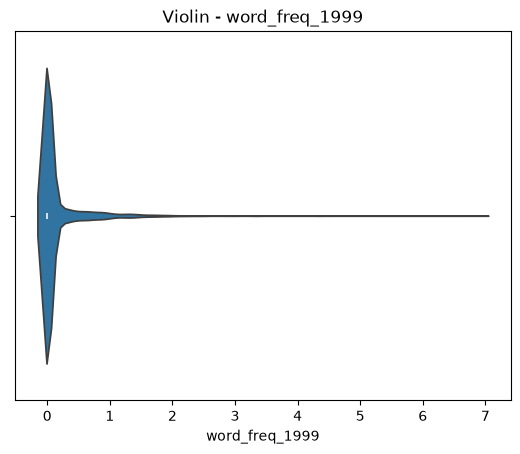

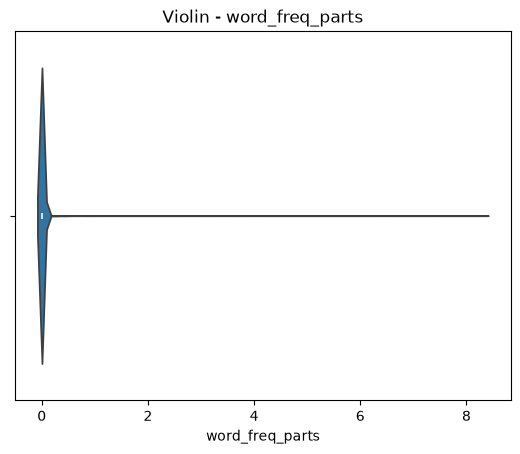

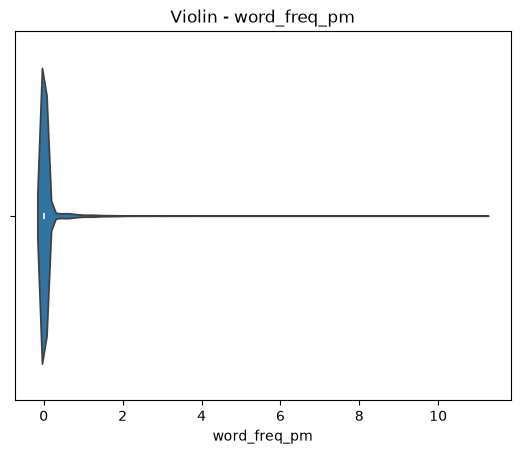

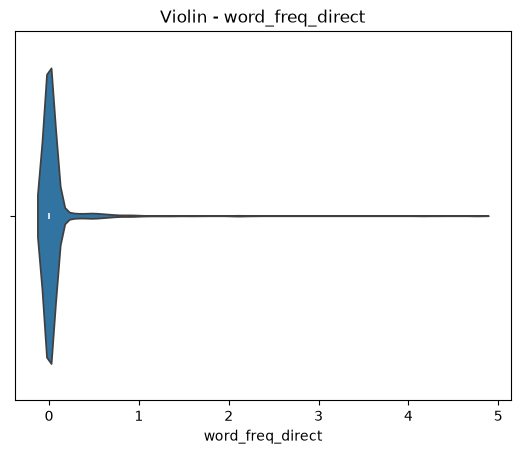

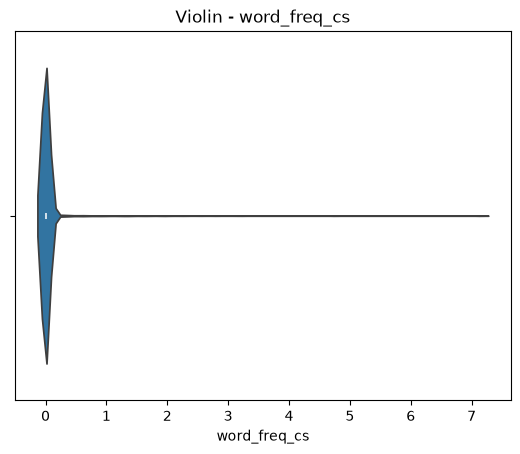

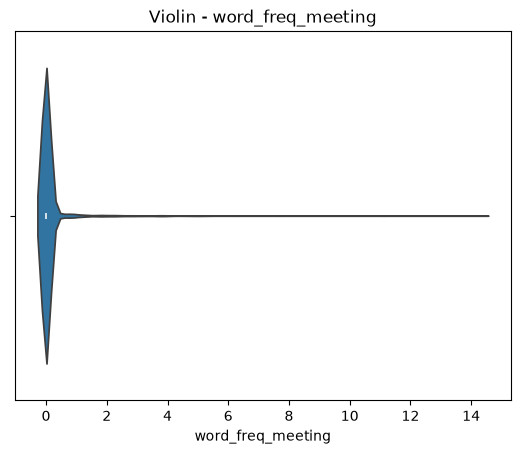

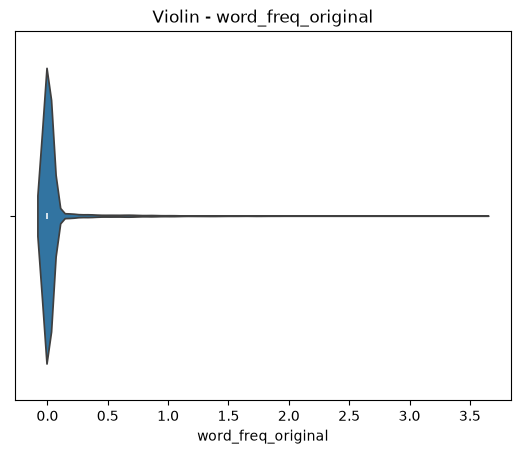

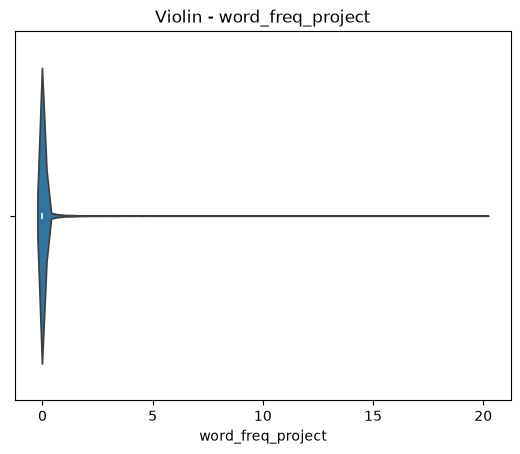

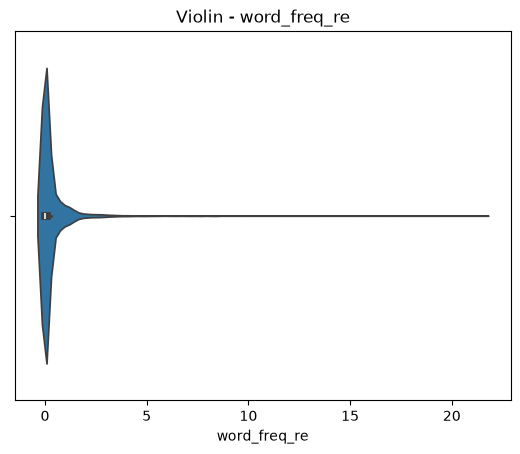

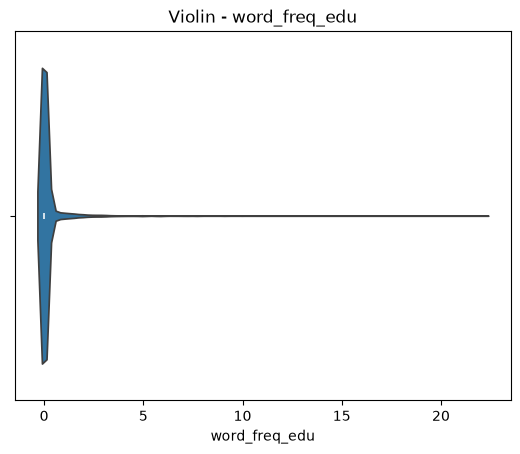

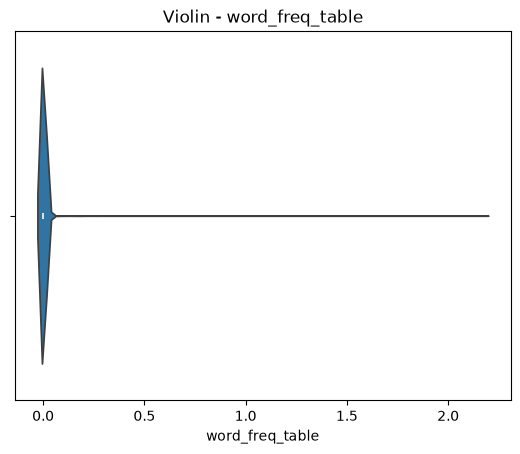

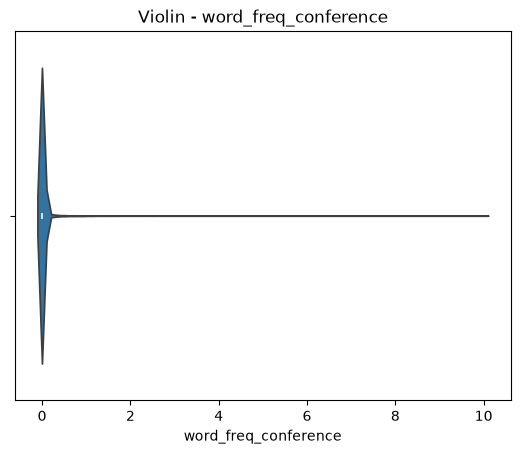

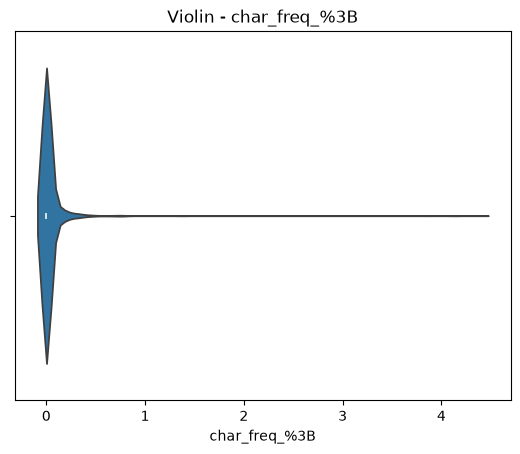

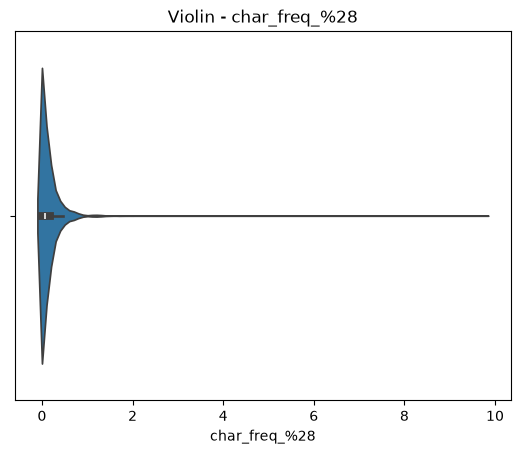

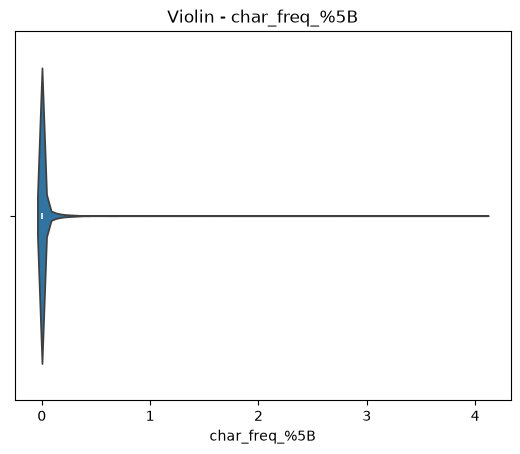

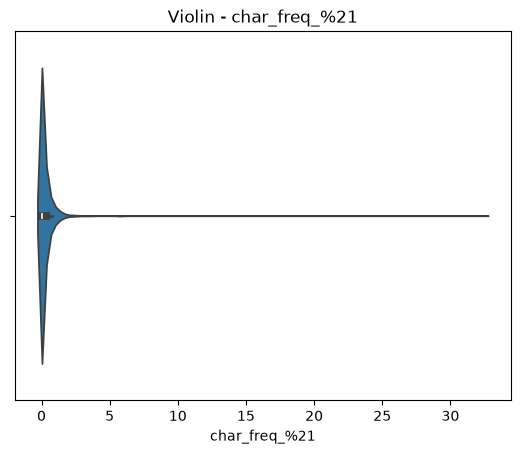

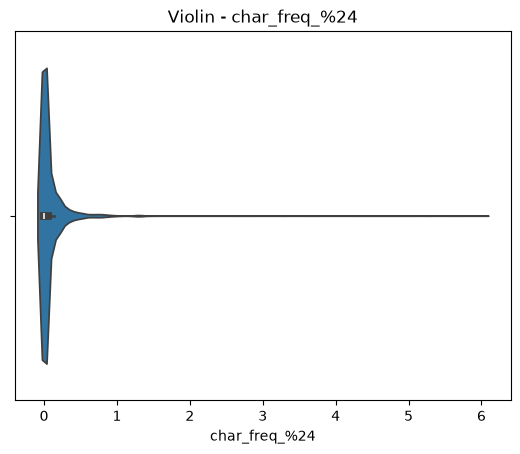

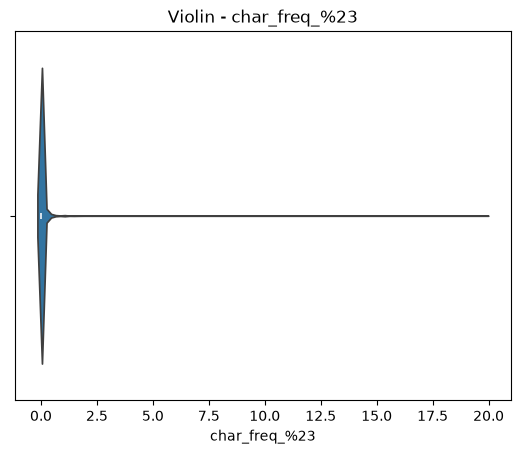

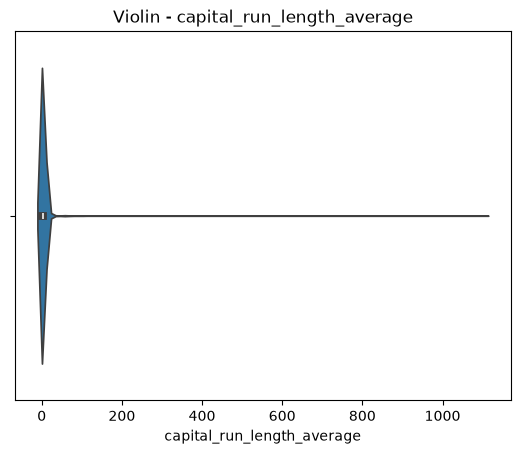

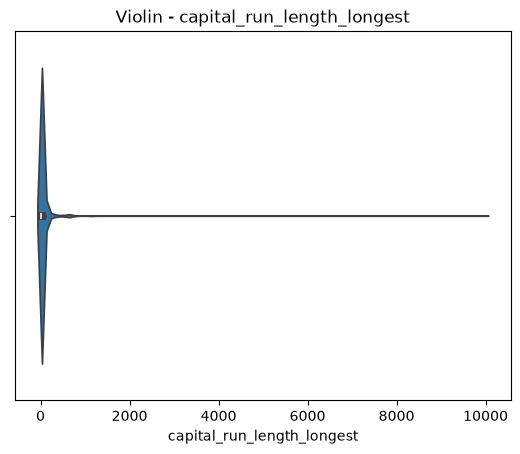

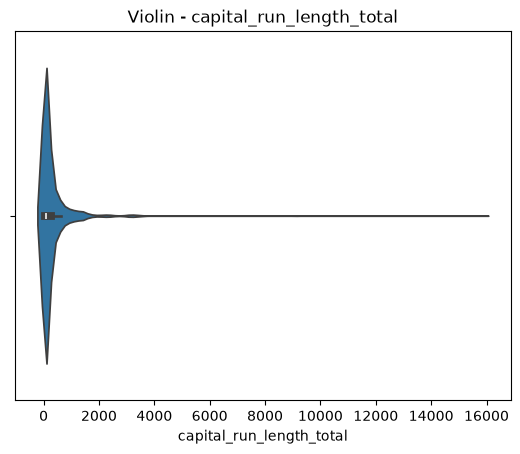

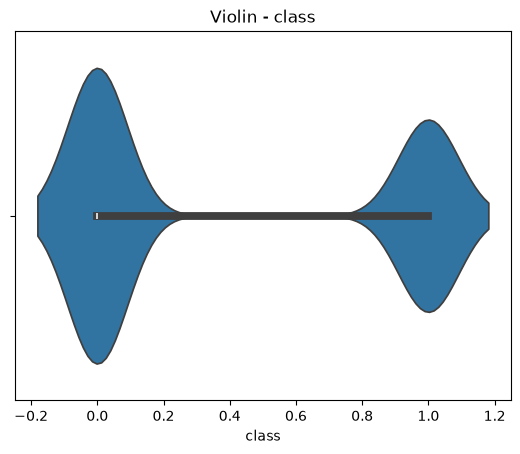

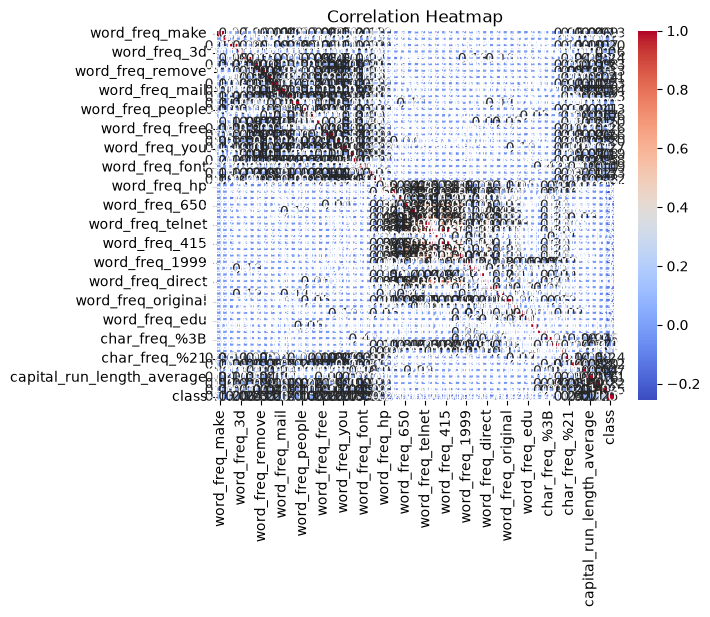

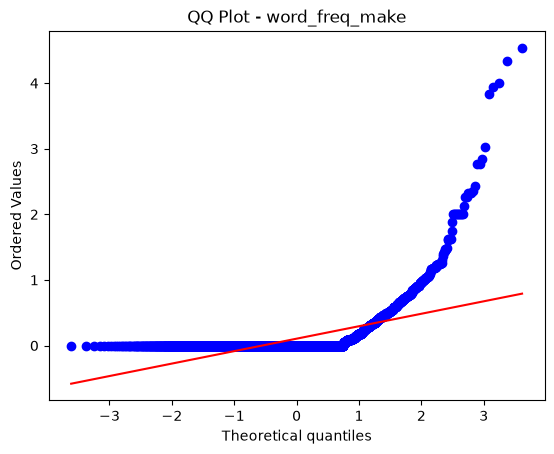

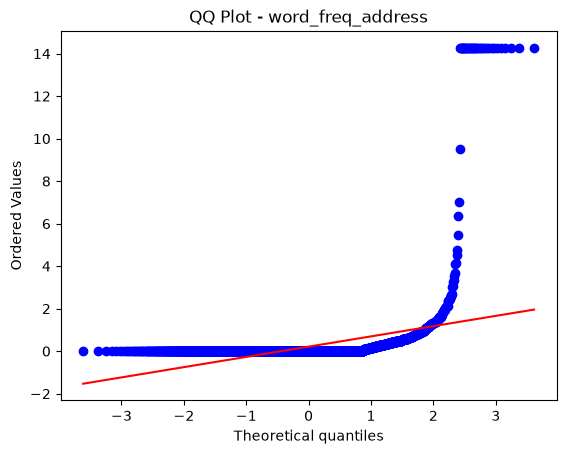

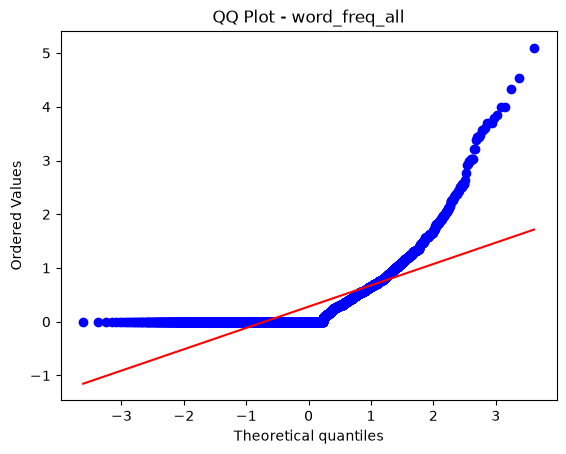

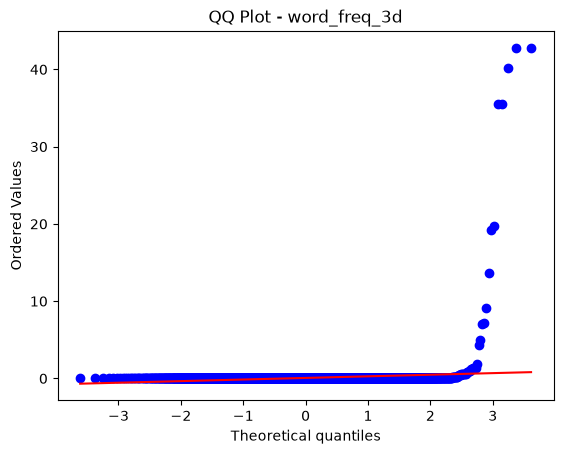

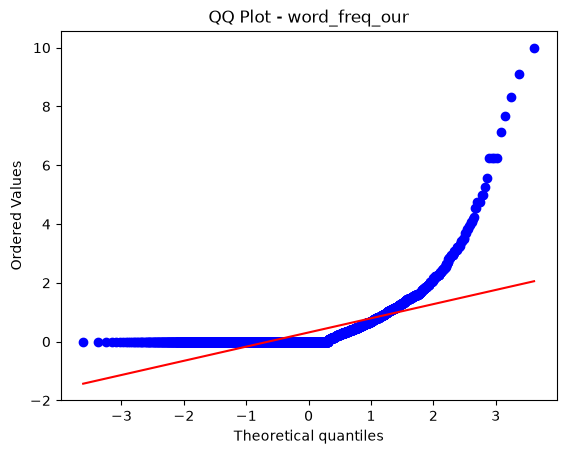

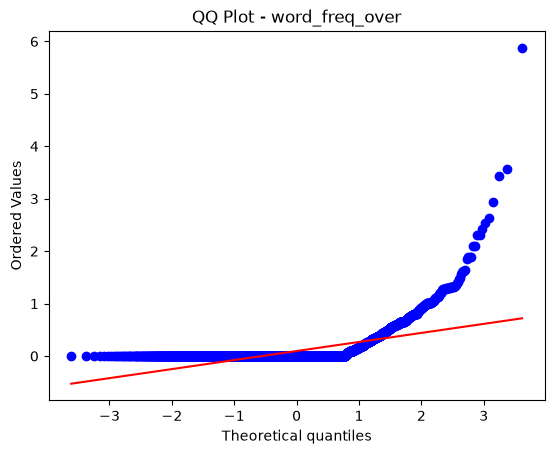

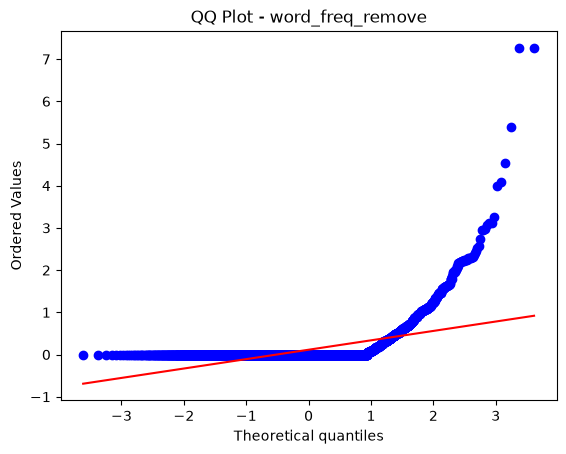

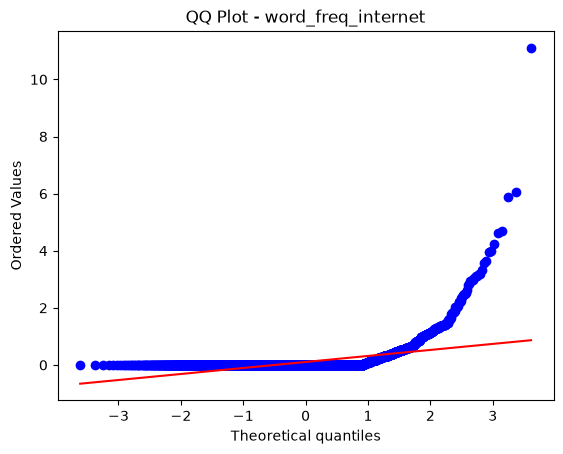

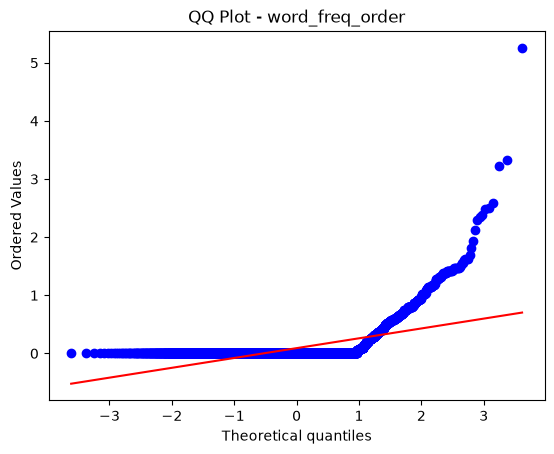

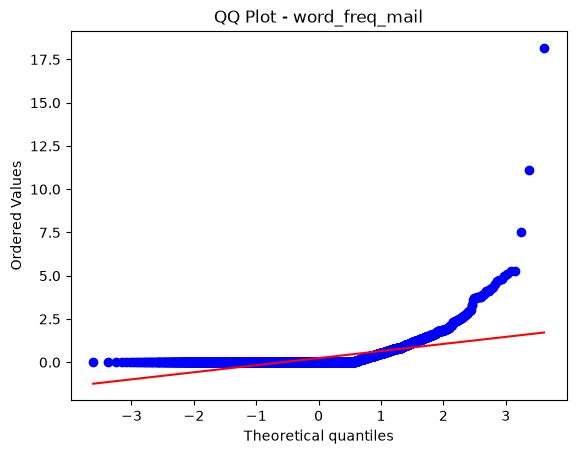

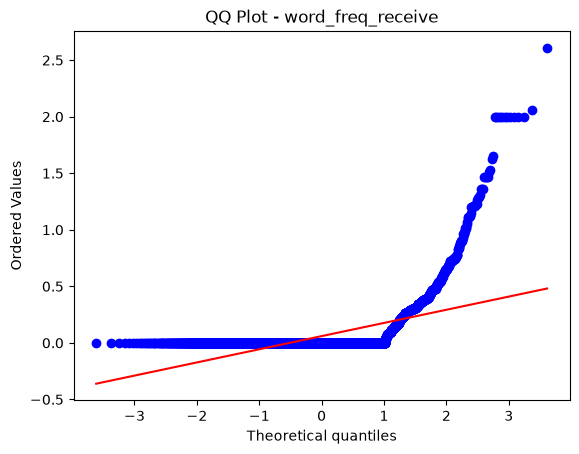

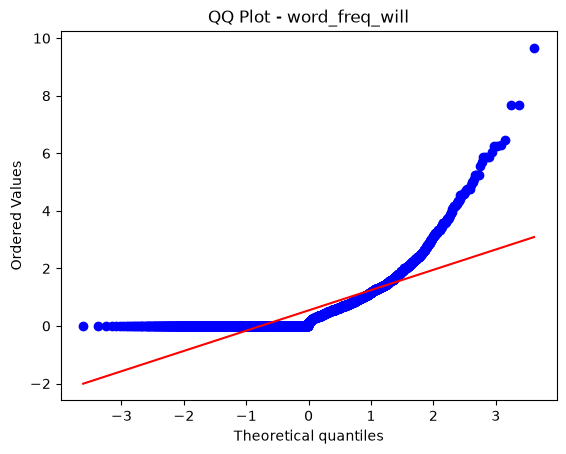

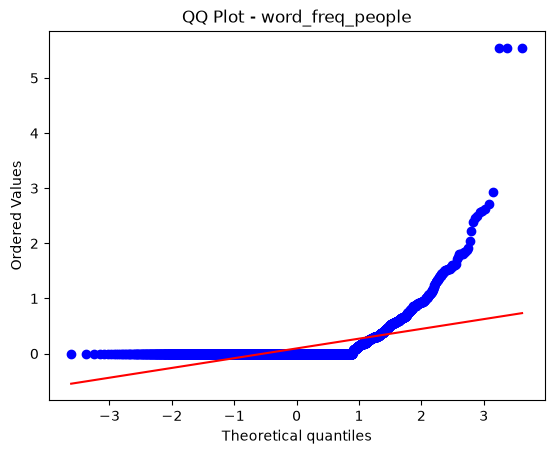

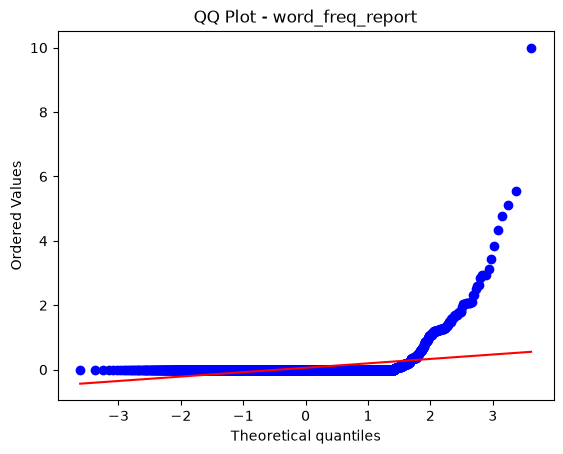

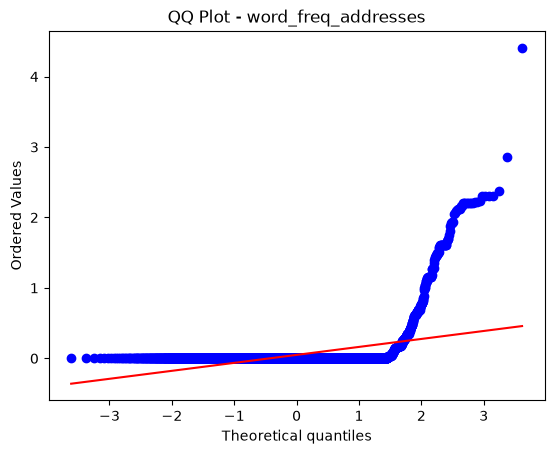

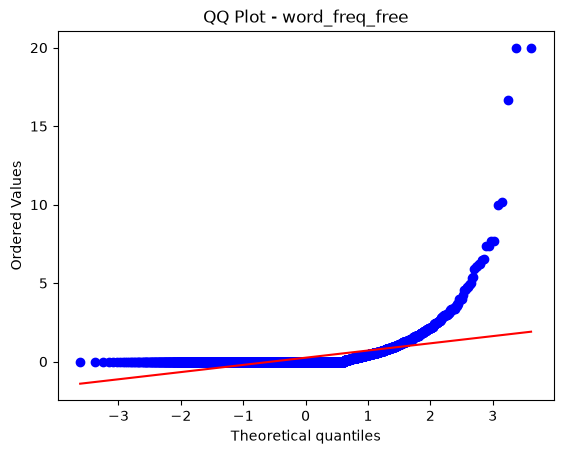

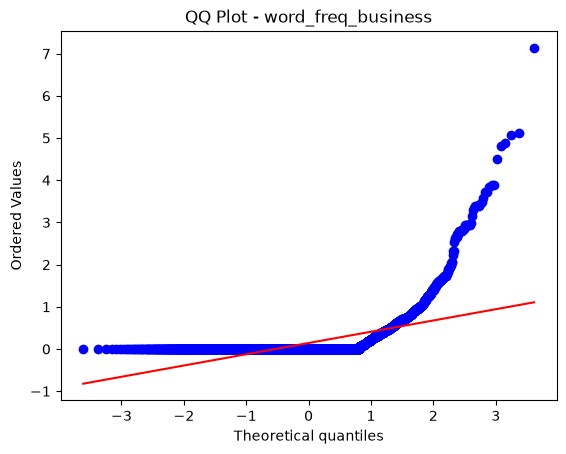

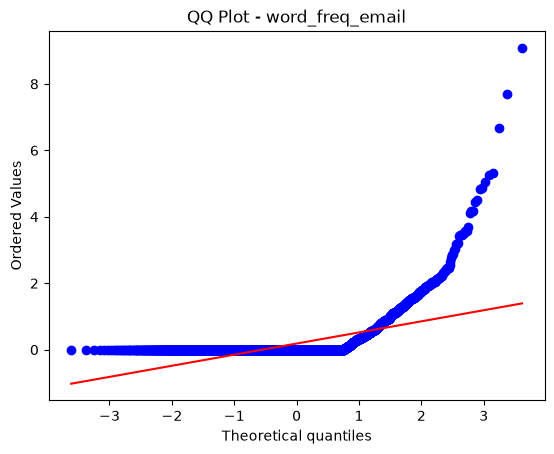

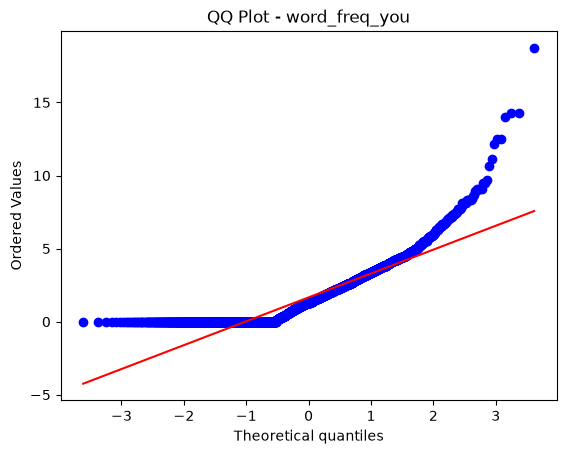

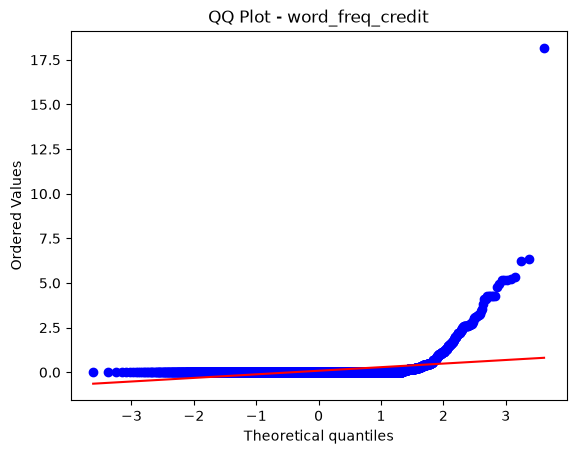

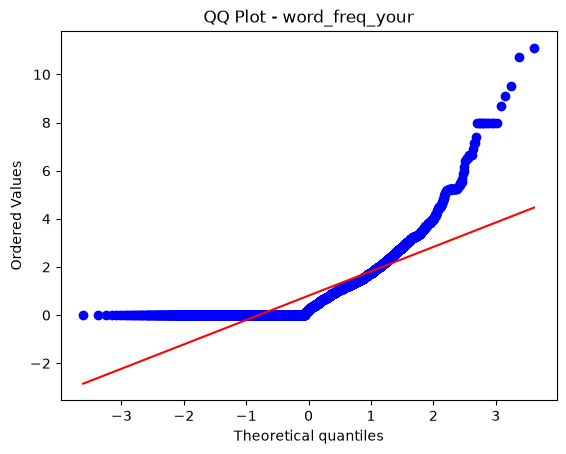

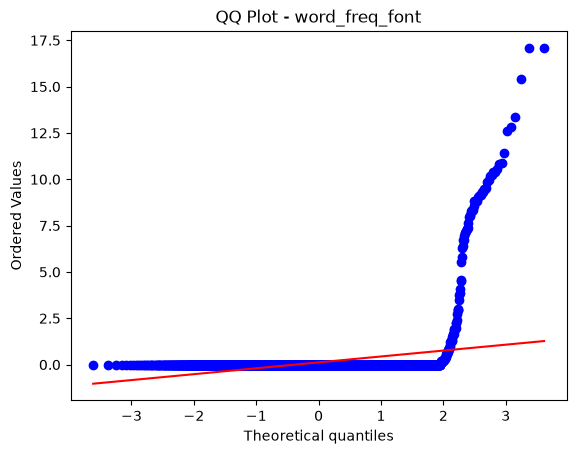

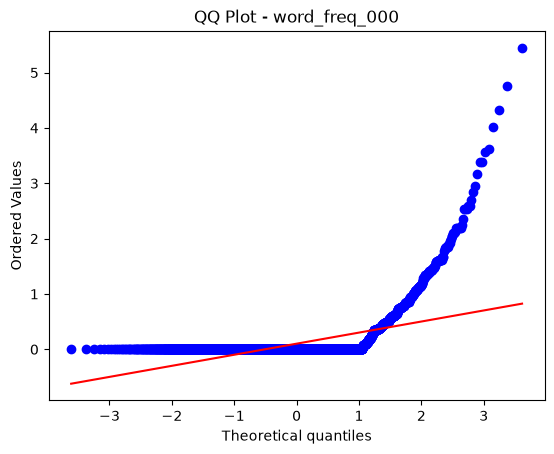

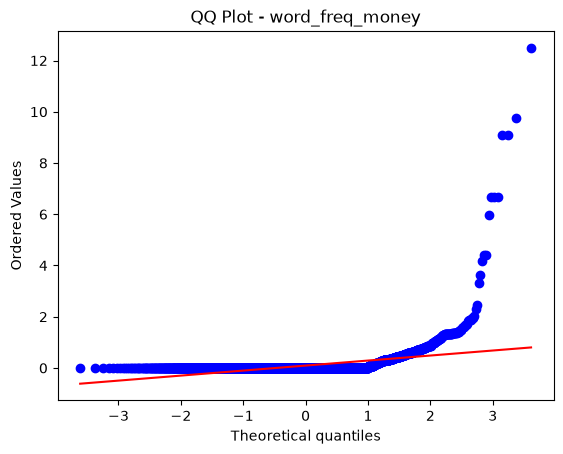

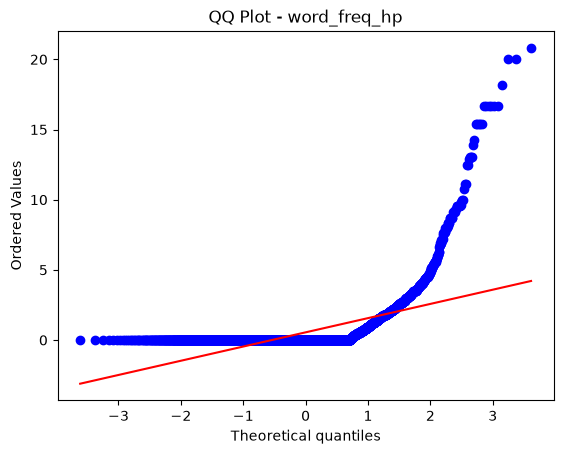

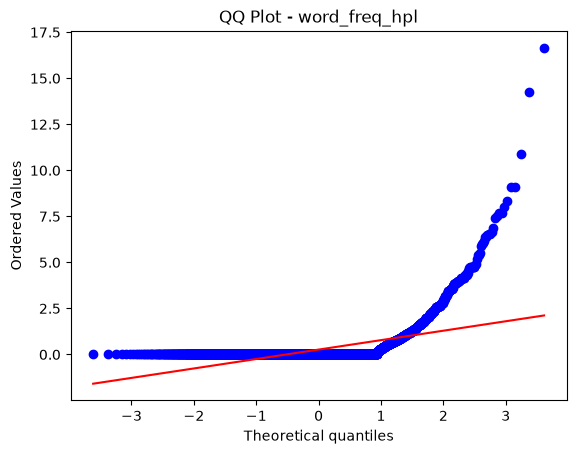

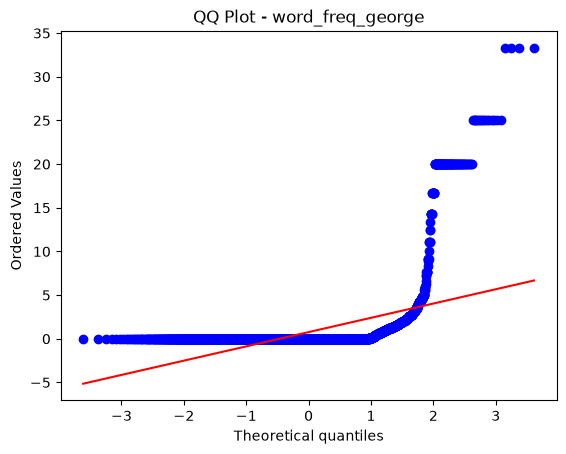

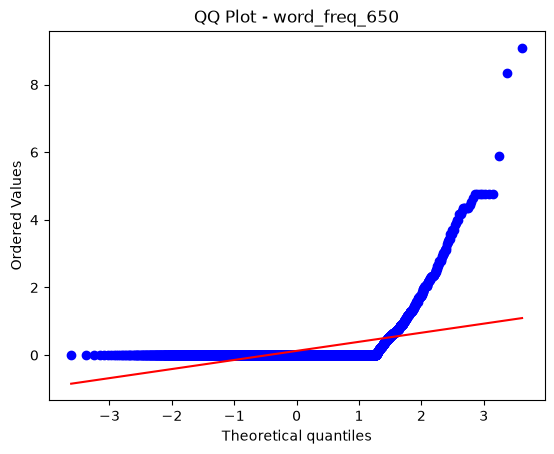

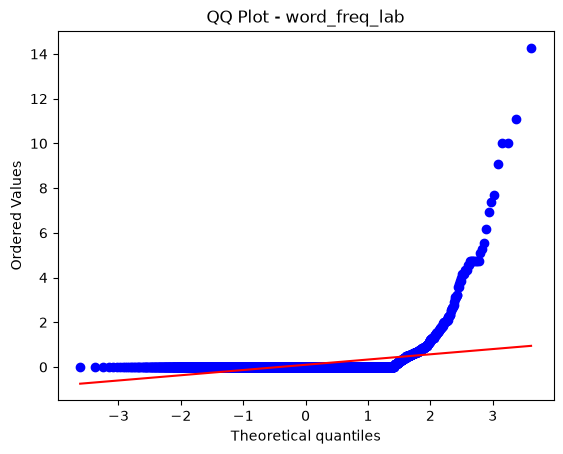

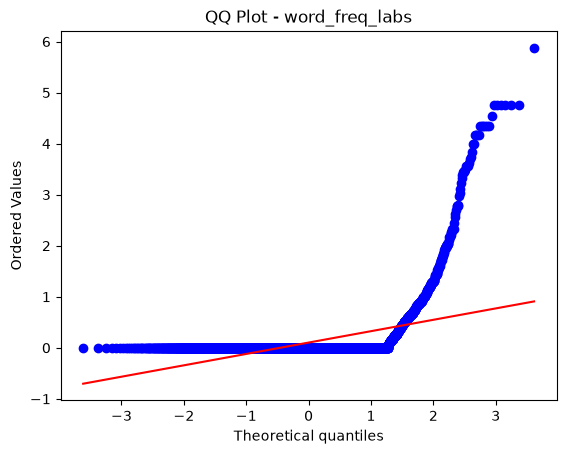

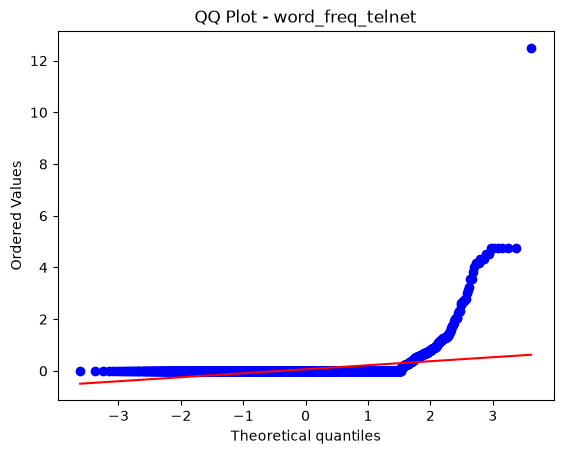

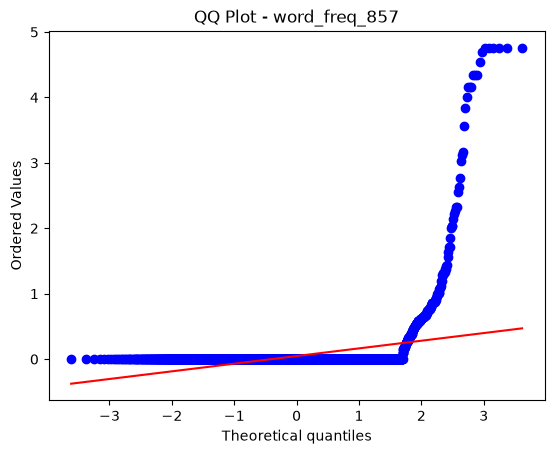

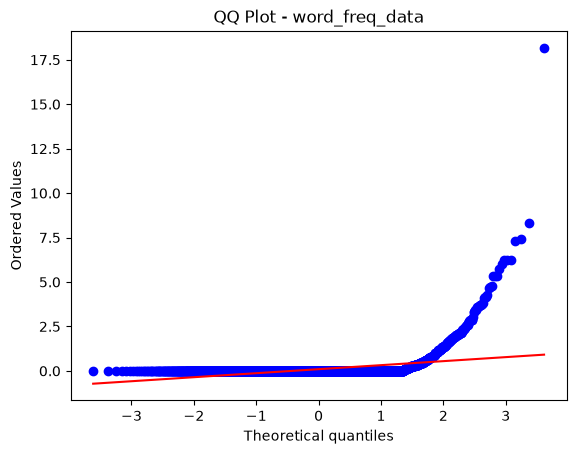

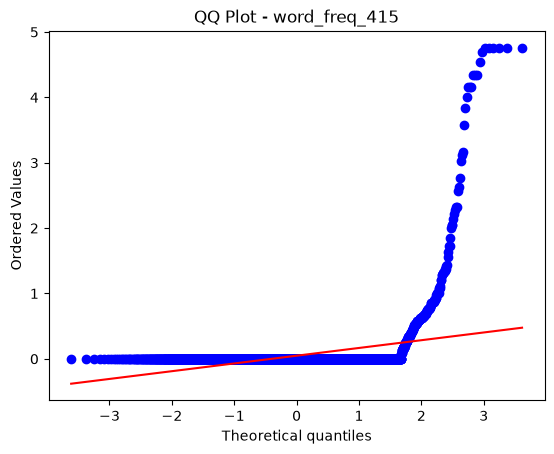

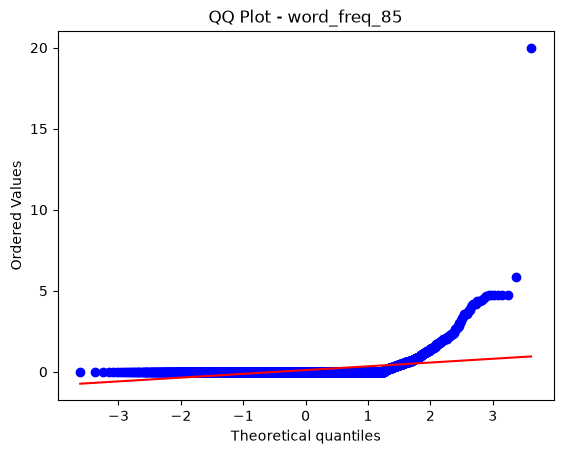

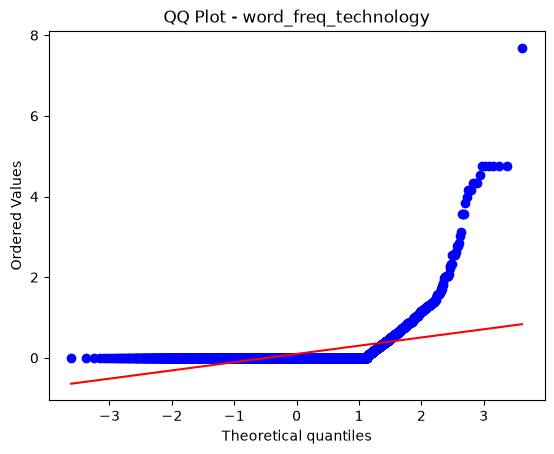

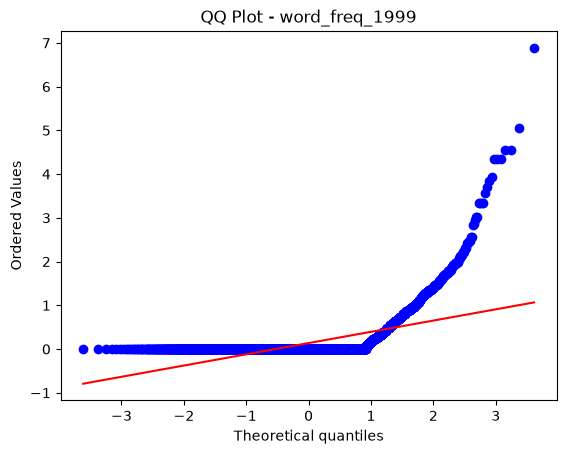

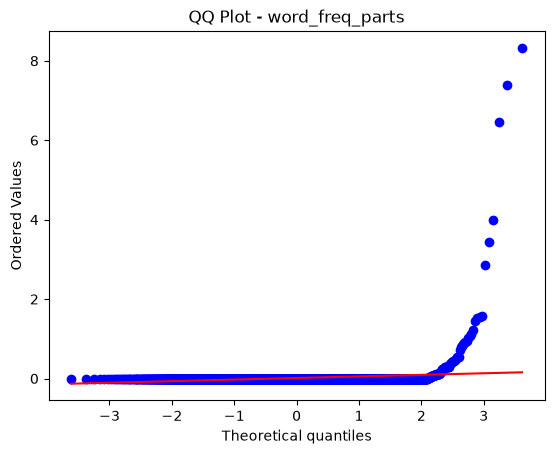

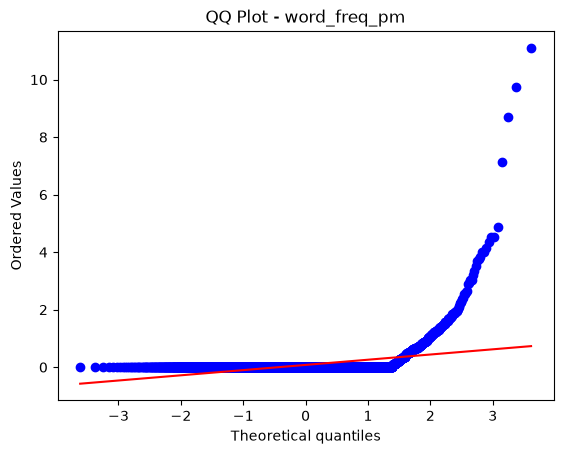

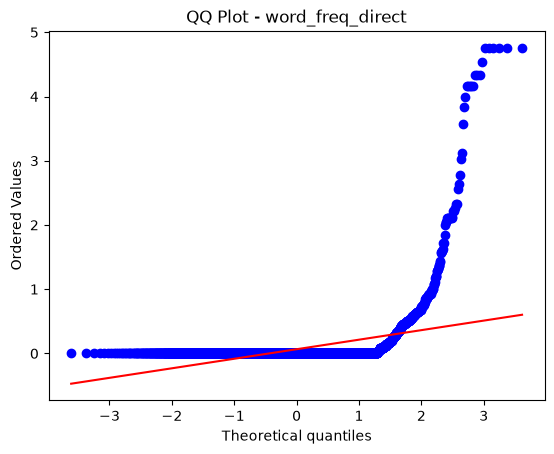

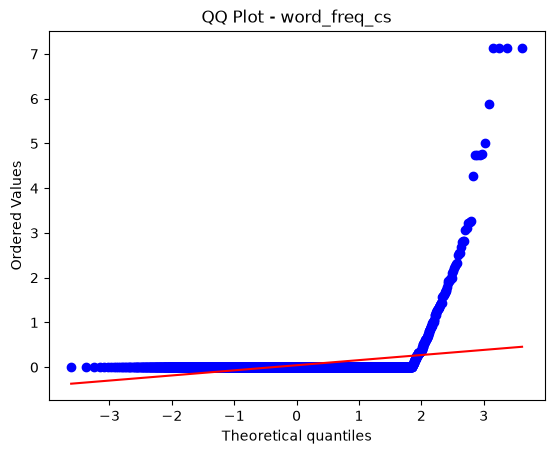

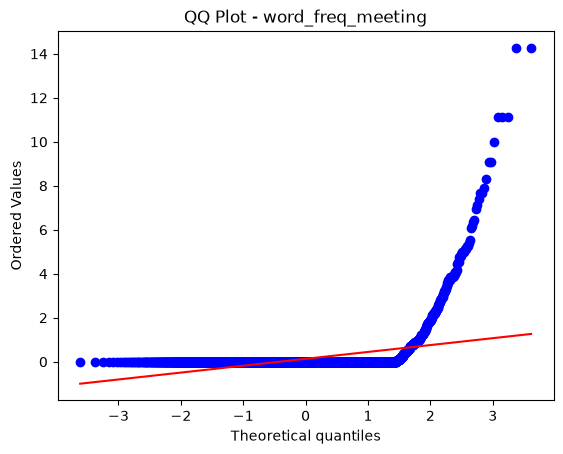

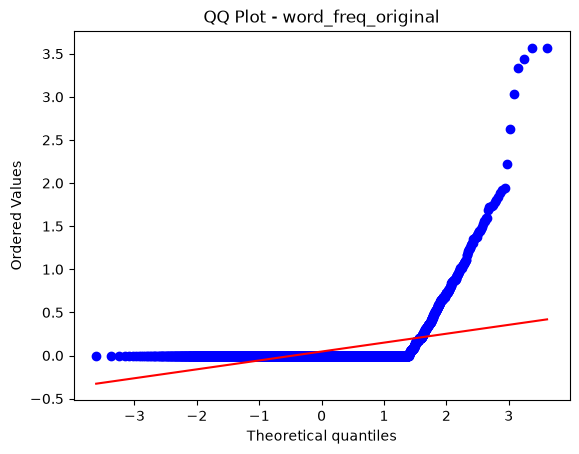

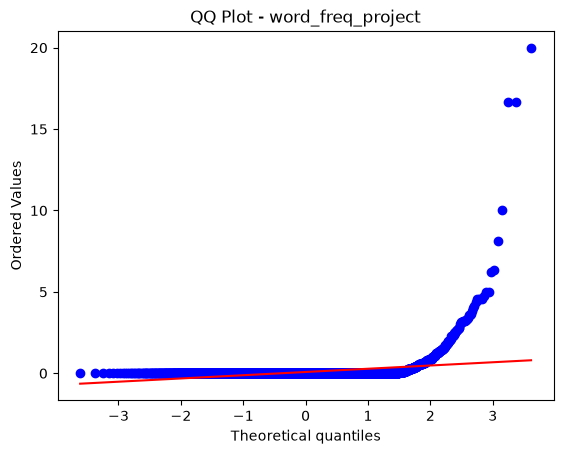

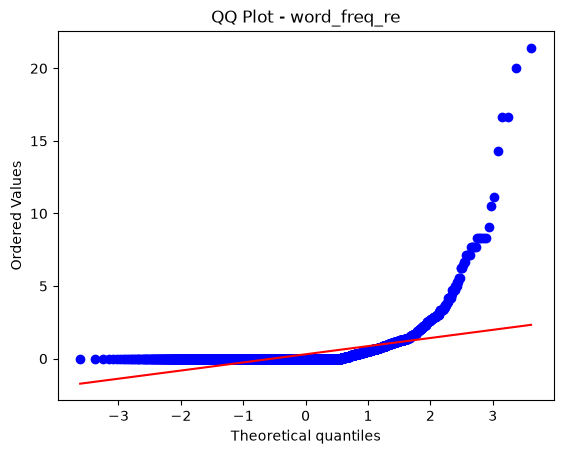

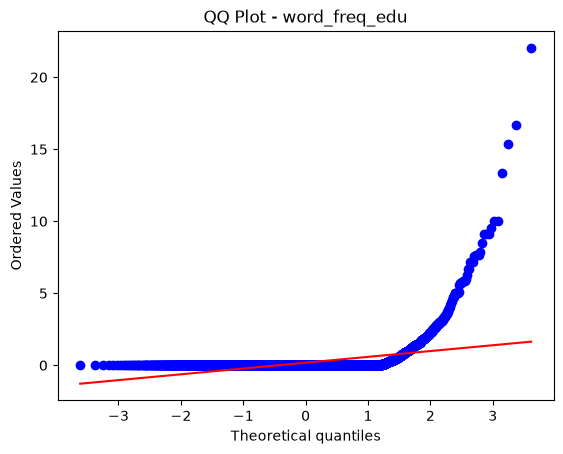

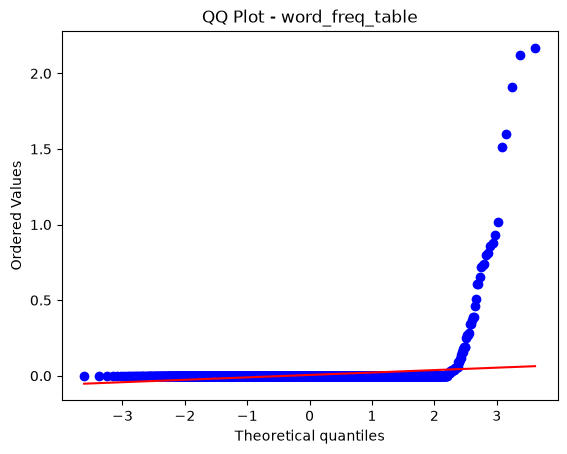

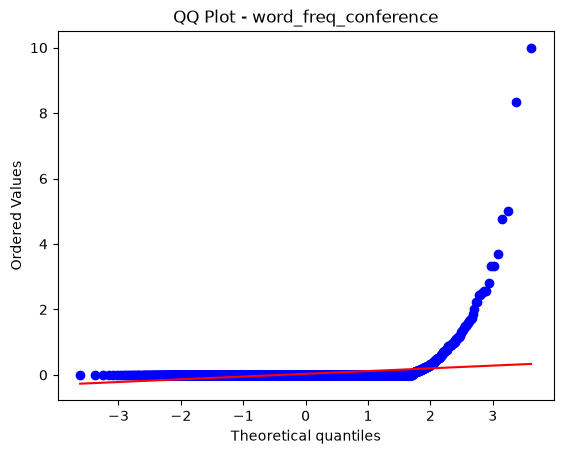

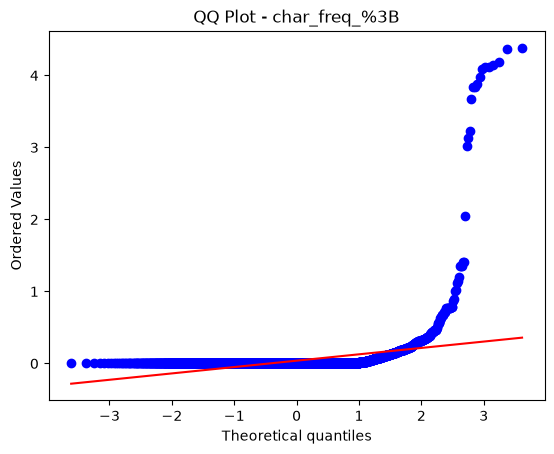

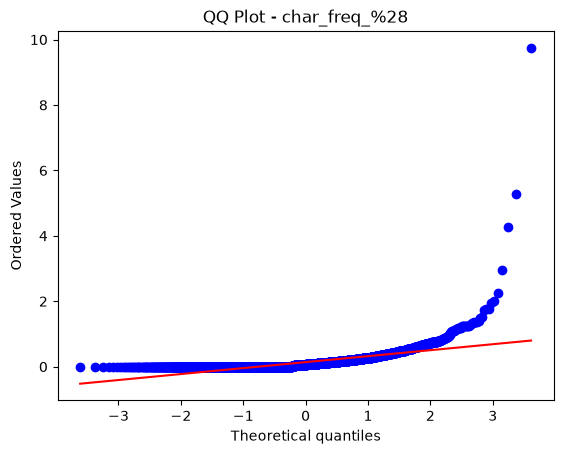

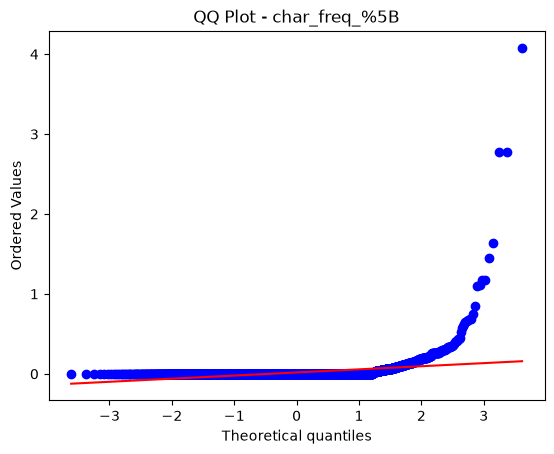

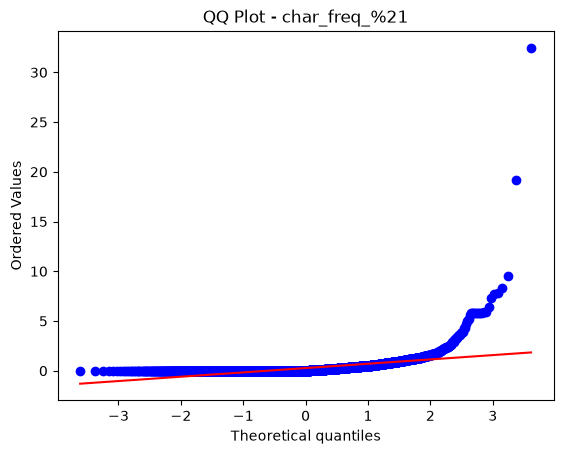

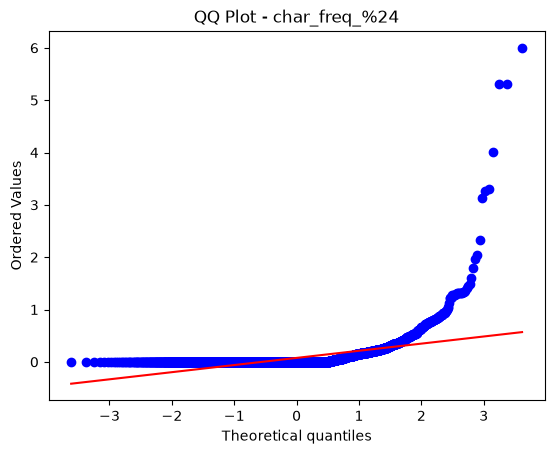

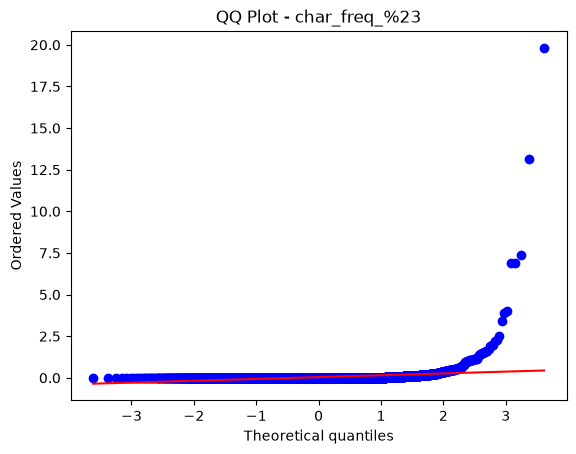

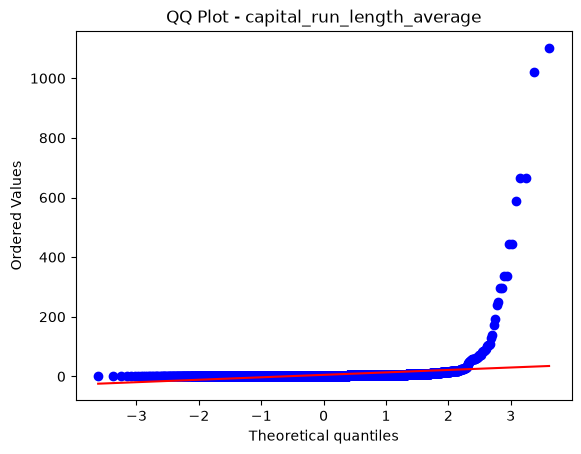

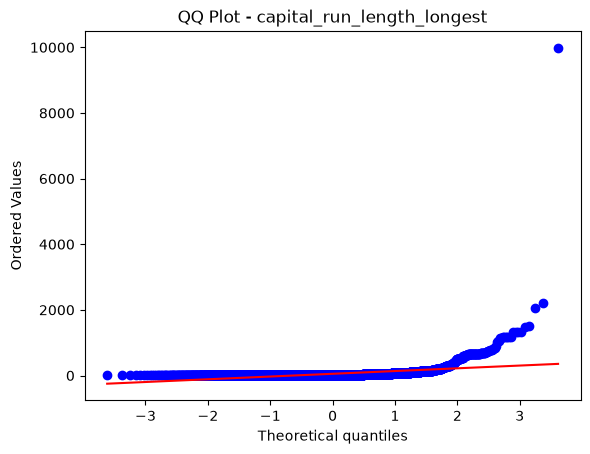

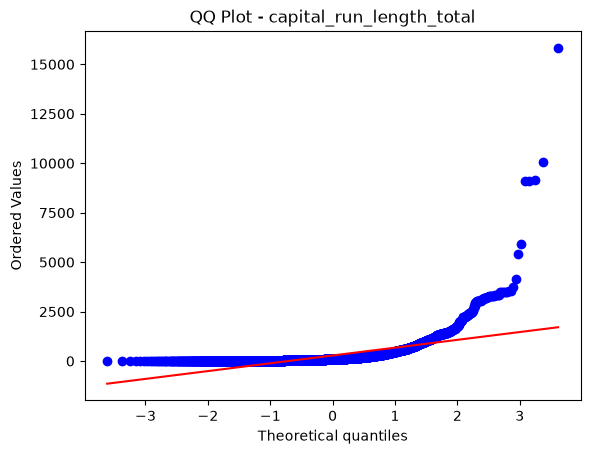

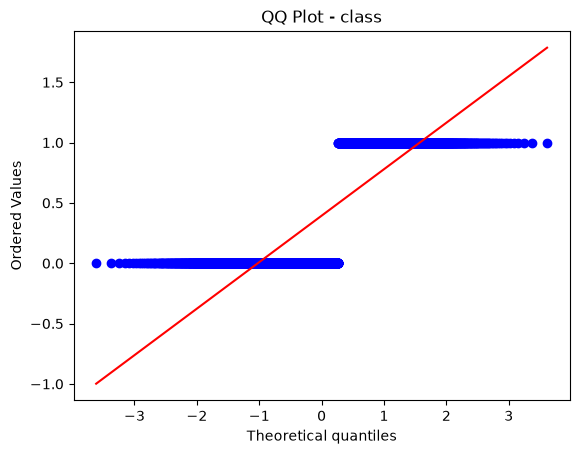


EDA Completed.


In [2]:
perform_eda("D:\Semester-5\Machine Learning - Lab\Assignment-2\dataset\spambase_csv.csv")